# Compare Auction Values

In [1]:
import pandas as pd
pd.options.display.precision = 2
import matplotlib.pyplot as plt

In [2]:
Num_teams = 12.
Team_budget = 400.
Hitter_sal_split = 0.53
Hitting_Pos = [
    'C',
    '1B',
    '2B',
    'SS',
    '3B',
    'OF',
    'Util',
    'MI'
]
Pitching_Pos = [
    'SP',
    'RP',
    'P'
]

All_Pos = Hitting_Pos + Pitching_Pos

#Jan23 2025 Roster totals
Replacement_Level = {
    'C':24,
    '1B':25,
    '2B':27,
    'SS':44,
    '3B':19,
    'MI':63,
    'OF':89,
    'Util':233,
    'SP':150,
    'RP':65,
    'P':215
}
Replacement_window = {
    'C':5,
    '1B':5,
    '2B':5,
    'SS':5,
    '3B':5,
    'MI':5,
    'OF':5,
    'Util':5,
    'SP':5,
    'RP':5,
    'P':5
}

In [3]:
# ADP First
Proj_cols = ['ADP_FGAV','TOTAL_SGP_Val_mySGP', 'Dollars_FGAV', 'Dollars_Vibbot']

In [4]:
League_path = '/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/Imaginary_Hammers/'

In [5]:
Format_Avg_path = '/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/Ottoneu/Latest_Ottoneu_4x4.csv'

In [6]:
League_Proj_files = {
    'Hitter_SGP':League_path+'Latest_Hitter_Proj.csv',
    'Pitcher_SGP':League_path+'Latest_Pitcher_Proj.csv',
    'FG_Auction_Hitter':League_path+'FG_Auction_Jan25_2026/fangraphs-auction-calculator_Hitters.csv',
    'FG_Auction_Pitcher':League_path+'FG_Auction_Jan25_2026/fangraphs-auction-calculator_Pitchers.csv',
    'Vibbot':League_path+'Vibbot_ATC_Proj_Jan26_2026.csv',
    'Ottoneu':Format_Avg_path,
    'Rosters':League_path+'Current_League_Rosters.csv'
}

In [7]:
Player_id_cols = [
    'FG ID','MLBAMID','Name','Team','NameASCII','Ottoneu ID','Ottoneu Positions'
]

In [8]:
Full_Merge_df = pd.DataFrame()

In [9]:
Player_ID_Map_Path = '/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/Player_ID_Map/Latest_Player_ID_Map.csv'

In [10]:
Player_ID_Map_df = pd.read_csv(Player_ID_Map_Path)
Player_ID_Map_df['FG ID'] = Player_ID_Map_df['FG ID'].astype(str)
Player_ID_Map_df['FG ID'] = Player_ID_Map_df['FG ID'].fillna(Player_ID_Map_df['FG Minor ID'])
Player_ID_Map_df['FG ID'] = Player_ID_Map_df['FG ID'].str.replace('.0','')
Player_ID_Map_df['Ottoneu ID'] = Player_ID_Map_df['Ottoneu ID'].astype(str)
Player_ID_Map_df['Ottoneu ID'] = Player_ID_Map_df['Ottoneu ID'].str.replace('.0','')

# My SGP Proj

In [11]:
Hitter_SGP_df = pd.read_csv(League_Proj_files['Hitter_SGP'])
Pitcher_SGP_df = pd.read_csv(League_Proj_files['Pitcher_SGP'])
Hitter_SGP_df.rename(columns={
    'PlayerId':'FG ID'
},inplace=True)
Pitcher_SGP_df.rename(columns={
    'PlayerId':'FG ID'
},inplace=True)

In [12]:
Hitter_SGP_df = Hitter_SGP_df.merge(Player_ID_Map_df[['FG ID','Ottoneu ID','Ottoneu Positions','Name']],how='inner')
Pitcher_SGP_df = Pitcher_SGP_df.merge(Player_ID_Map_df[['FG ID','Ottoneu ID','Ottoneu Positions','Name']],how='inner')

In [13]:
Hitter_Pitcher_SGP_df = pd.concat(
    [
        Hitter_SGP_df,
        Pitcher_SGP_df
    ]
)

In [14]:
Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['Ottoneu ID'].isin([key for key, val in Hitter_Pitcher_SGP_df['Ottoneu ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,MLBAMID,Name,Team,NameASCII,G,PA,AB,H,1B,...,ERA_SGP_raw,WHIP_SGP_raw,K_SGP_norm,HR9_SGP_norm,ERA_SGP_norm,WHIP_SGP_norm,K_SGP_Val,HR9_SGP_Val,ERA_SGP_Val,WHIP_SGP_Val
150,19755,660271,Shohei Ohtani,LAD,Shohei Ohtani,154.56,675.76,576.21,164.76,82.64,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
172,19755,660271,Shohei Ohtani,LAD,Shohei Ohtani,22.14,NaN,NaN,87.14,NaN,...,0.55,0.5,0.83,0.6,0.87,0.8,12.89,14.69,17.23,19.02


In [15]:
Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['FG ID'] == '19755']

,FG ID,MLBAMID,Name,Team,NameASCII,G,PA,AB,H,1B,...,ERA_SGP_raw,WHIP_SGP_raw,K_SGP_norm,HR9_SGP_norm,ERA_SGP_norm,WHIP_SGP_norm,K_SGP_Val,HR9_SGP_Val,ERA_SGP_Val,WHIP_SGP_Val
150,19755,660271,Shohei Ohtani,LAD,Shohei Ohtani,154.56,675.76,576.21,164.76,82.64,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
172,19755,660271,Shohei Ohtani,LAD,Shohei Ohtani,22.14,NaN,NaN,87.14,NaN,...,0.55,0.5,0.83,0.6,0.87,0.8,12.89,14.69,17.23,19.02


In [16]:
Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755'].columns

Index(['FG ID', 'MLBAMID', 'Name', 'Team', 'NameASCII', 'W', 'L', 'QS', 'G',
       'GS', 'SV', 'HLD', 'IP', 'TBF', 'H', 'R', 'ER', 'HR', 'BB', 'HBP', 'SO',
       'WAR', 'ADP', 'POS', 'K', 'HR9', 'ERA', 'WHIP', 'Pos Place',
       'K_SGP_raw', 'HR9_SGP_raw', 'ERA_SGP_raw', 'WHIP_SGP_raw',
       'TOTAL_SGP_raw', 'K_SGP_norm', 'HR9_SGP_norm', 'ERA_SGP_norm',
       'WHIP_SGP_norm', 'TOTAL_SGP', 'TOTAL_SGP_Rank', 'TOTAL_SGP_Val',
       'K_SGP_Val', 'HR9_SGP_Val', 'ERA_SGP_Val', 'WHIP_SGP_Val', 'Ottoneu ID',
       'Ottoneu Positions'],
      dtype='str')

In [17]:
#Handle Othtani...
Ohtani_df = pd.DataFrame([
    {
        'FG ID':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['FG ID'].values[0],
        'MLBAMID':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['MLBAMID'].values[0],
        'Name':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['Name'].values[0],
        'Team':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['Team'].values[0],
        'NameASCII':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['NameASCII'].values[0],
        'G':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['G'].values[0],
        'PA':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['PA'].values[0],
        'AB':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['AB'].values[0],
        'H':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['H'].values[0],
        '1B':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['1B'].values[0], 
        '2B':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['2B'].values[0], 
        '3B':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['3B'].values[0],
        'HR':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['HR'].values[0],
        'R':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['R'].values[0],
        'RBI':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['RBI'].values[0],
        'BB':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['BB'].values[0],
        'HBP':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['HBP'].values[0],
        'SF':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['SF'].values[0],
        'WAR':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['WAR'].values[0],
        'ADP':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['ADP'].values[0],
        'POS':"['DH','SP']",
        'OBP':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['OBP'].values[0], 
        'TB':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['TB'].values[0], 
        'SLG':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['SLG'].values[0], 
        'Pos Place':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['Pos Place'].values[0], 
        'R_SGP_raw':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['R_SGP_raw'].values[0], 
        'HR_SGP_raw':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['HR_SGP_raw'].values[0],
        'OBP_SGP_raw':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['OBP_SGP_raw'].values[0], 
        'SLG_SGP_raw':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['SLG_SGP_raw'].values[0], 
        'TOTAL_SGP_raw':Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['FG ID'] == '19755']['TOTAL_SGP_raw'].sum(), 
        'R_SGP_norm':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['R_SGP_norm'].values[0],
        'HR_SGP_norm':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['HR_SGP_norm'].values[0], 
        'OBP_SGP_norm':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['OBP_SGP_norm'].values[0], 
        'SLG_SGP_norm':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['SLG_SGP_norm'].values[0], 
        'TOTAL_SGP':Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['FG ID'] == '19755']['TOTAL_SGP'].sum(),
        'TOTAL_SGP_Rank':Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['FG ID'] == '19755']['TOTAL_SGP_Rank'].min(), 
        'R_SGP_Val':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['R_SGP_Val'].values[0], 
        'HR_SGP_Val':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['HR_SGP_Val'].values[0],
        'OBP_SGP_Val':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['OBP_SGP_Val'].values[0], 
        'SLG_SGP_Val':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['SLG_SGP_Val'].values[0],
        'W':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['W'].values[0], 
        'L':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['L'].values[0], 
        'QS':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['QS'].values[0], 
        #'G':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['G'].values[0],
        'GS':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['GS'].values[0], 
        'SV':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['SV'].values[0], 
        'HLD':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['HLD'].values[0], 
        'IP':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['IP'].values[0], 
        'TBF':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['TBF'].values[0], 
        #'H':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['H'].values[0], 
        #'R':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['R'].values[0], 
        'ER':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['ER'].values[0], 
        #'HR':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['HR'].values[0], 
        #'BB':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['BB'].values[0], 
        #'HBP':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['HBP'].values[0], 
        'SO':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['SO'].values[0],
        #'WAR':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['WAR'].values[0], 
        #'ADP':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['ADP'].values[0], 
        #'POS':"['DH','SP']", 
        #'K':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['K'].values[0], 
        'HR9':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['HR9'].values[0], 
        'ERA':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['ERA'].values[0], 
        'WHIP':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['WHIP'].values[0], 
        #'Pos Place':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['Pos Place'].values[0],
        'K_SGP_raw':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['K_SGP_raw'].values[0], 
        'HR9_SGP_raw':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['HR9_SGP_raw'].values[0],
        'ERA_SGP_raw':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['ERA_SGP_raw'].values[0], 
        'WHIP_SGP_raw':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['WHIP_SGP_raw'].values[0],
        #'TOTAL_SGP_raw', 
        'K_SGP_norm':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['K_SGP_norm'].values[0], 
        'HR9_SGP_norm':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['HR9_SGP_norm'].values[0], 
        'ERA_SGP_norm':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['ERA_SGP_norm'].values[0],
        'WHIP_SGP_norm':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['WHIP_SGP_norm'].values[0], 
        #'TOTAL_SGP', 
        #'TOTAL_SGP_Rank', 
        'K_SGP_Val':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['K_SGP_Val'].values[0], 
        'HR9_SGP_Val':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['HR9_SGP_Val'].values[0], 
        'ERA_SGP_Val':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['ERA_SGP_Val'].values[0], 
        'WHIP_SGP_Val':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['WHIP_SGP_Val'].values[0],
        'TOTAL_SGP_Val':Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['FG ID'] == '19755']['TOTAL_SGP_Val'].sum(),
        'Ottoneu ID':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['Ottoneu ID'].values[0],
        'Ottoneu Positions':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['Ottoneu Positions'].values[0],
    }
])

In [18]:
Hitter_Pitcher_SGP_df.drop_duplicates(['FG ID'],keep=False,inplace=True)

In [19]:
Hitter_Pitcher_SGP_df = pd.concat([
    Hitter_Pitcher_SGP_df,
    Ohtani_df
])

In [20]:
Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['FG ID'] == '19755']

,FG ID,MLBAMID,Name,Team,NameASCII,G,PA,AB,H,1B,...,ERA_SGP_raw,WHIP_SGP_raw,K_SGP_norm,HR9_SGP_norm,ERA_SGP_norm,WHIP_SGP_norm,K_SGP_Val,HR9_SGP_Val,ERA_SGP_Val,WHIP_SGP_Val
0,19755,660271,Shohei Ohtani,LAD,Shohei Ohtani,154.56,675.76,576.21,164.76,82.64,...,0.55,0.5,0.83,0.6,0.87,0.8,12.89,14.69,17.23,19.02


In [21]:
Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['Ottoneu ID'].isin([key for key, val in Hitter_Pitcher_SGP_df['Ottoneu ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,MLBAMID,Name,Team,NameASCII,G,PA,AB,H,1B,...,ERA_SGP_raw,WHIP_SGP_raw,K_SGP_norm,HR9_SGP_norm,ERA_SGP_norm,WHIP_SGP_norm,K_SGP_Val,HR9_SGP_Val,ERA_SGP_Val,WHIP_SGP_Val


In [22]:
Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['Ottoneu ID'].isin([key for key, val in Hitter_Pitcher_SGP_df['Ottoneu ID'].value_counts().to_dict().items() if val != 1])].sort_values('Name')

,FG ID,MLBAMID,Name,Team,NameASCII,G,PA,AB,H,1B,...,ERA_SGP_raw,WHIP_SGP_raw,K_SGP_norm,HR9_SGP_norm,ERA_SGP_norm,WHIP_SGP_norm,K_SGP_Val,HR9_SGP_Val,ERA_SGP_Val,WHIP_SGP_Val


In [23]:
Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['Ottoneu ID'].isna()]

,FG ID,MLBAMID,Name,Team,NameASCII,G,PA,AB,H,1B,...,ERA_SGP_raw,WHIP_SGP_raw,K_SGP_norm,HR9_SGP_norm,ERA_SGP_norm,WHIP_SGP_norm,K_SGP_Val,HR9_SGP_Val,ERA_SGP_Val,WHIP_SGP_Val


In [24]:
Full_Merge_df = Hitter_Pitcher_SGP_df.rename(columns={c: c+'_mySGP' for c in Hitter_Pitcher_SGP_df.columns if c not in Player_id_cols})

In [25]:
Full_Merge_df.sort_values('TOTAL_SGP_Val_mySGP',ascending=False).head()

,FG ID,MLBAMID,Name,Team,NameASCII,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,...,ERA_SGP_raw_mySGP,WHIP_SGP_raw_mySGP,K_SGP_norm_mySGP,HR9_SGP_norm_mySGP,ERA_SGP_norm_mySGP,WHIP_SGP_norm_mySGP,K_SGP_Val_mySGP,HR9_SGP_Val_mySGP,ERA_SGP_Val_mySGP,WHIP_SGP_Val_mySGP
0,19755,660271,Shohei Ohtani,LAD,Shohei Ohtani,154.56,675.76,576.21,164.76,82.64,...,0.55,0.50,0.83,0.60,0.87,0.80,12.89,14.69,17.23,19.02
52,15640,592450,Aaron Judge,NYY,Aaron Judge,153.03,662.06,537.95,160.62,82.24,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
270,22267,669373,Tarik Skubal,DET,Tarik Skubal,31.15,NaN,NaN,153.77,NaN,...,1.49,1.57,3.03,1.43,1.81,1.87,46.90,34.72,35.96,44.43
551,31757,695243,Mason Miller,SDP,Mason Miller,64.24,NaN,NaN,39.24,NaN,...,2.24,2.14,0.74,1.22,3.00,2.94,11.46,29.69,59.70,69.67
144,19611,665489,Vladimir Guerrero Jr.,TOR,Vladimir Guerrero Jr.,156.37,676.03,588.64,176.89,110.62,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
Full_Merge_df.shape

(2661, 69)

# FanGraphs Auction Proj

In [27]:
FG_Auction_Hitter_df = pd.read_csv(League_Proj_files['FG_Auction_Hitter'])
FG_Auction_Pitcher_df = pd.read_csv(League_Proj_files['FG_Auction_Pitcher'])
FG_Auction_Hitter_df.rename(columns={
    'PlayerId':'FG ID'
},inplace=True)
FG_Auction_Pitcher_df.rename(columns={
    'PlayerId':'FG ID'
},inplace=True)

In [28]:
FG_Auction_Hitter_df = FG_Auction_Hitter_df.drop(columns=['Name','Team']).merge(Player_ID_Map_df[['FG ID','Ottoneu ID','Ottoneu Positions','Name']],how='inner')
FG_Auction_Pitcher_df = FG_Auction_Pitcher_df.drop(columns=['Name','Team']).merge(Player_ID_Map_df[['FG ID','Ottoneu ID','Ottoneu Positions','Name']],how='inner')

In [29]:
Auction_Hitter_FGAV_df = pd.concat(
    [
        FG_Auction_Hitter_df,
        FG_Auction_Pitcher_df
    ]
)

In [30]:
Auction_Hitter_FGAV_df = Auction_Hitter_FGAV_df.rename(columns={c: c+'_FGAV' for c in Auction_Hitter_FGAV_df.columns if c not in Player_id_cols})

In [31]:
Auction_Hitter_FGAV_df.shape

(1336, 20)

In [32]:
Full_Merge_df = Full_Merge_df.merge(Auction_Hitter_FGAV_df,how='outer')

In [33]:
Full_Merge_df.shape

(2958, 83)

In [34]:
Full_Merge_df.head()

,FG ID,MLBAMID,Name,Team,NameASCII,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,...,mHR_FGAV,mOBP_FGAV,mSLG_FGAV,PTS_FGAV,aPOS_FGAV,Dollars_FGAV,IP_FGAV,mERA_FGAV,mWHIP_FGAV,mSO_FGAV
0,10028,542194,Christian Bethancourt,CHC,Christian Bethancourt,0.00,1.00,1.00,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10061,548384,Brooks Raley,NYM,Brooks Raley,60.70,NaN,NaN,50.97,NaN,...,3.19,NaN,NaN,-9.29,4.12,-4.17,62.0,-3.32,-4.81,-4.35
2,10078,573204,Caleb Thielbar,CHC,Caleb Thielbar,65.71,NaN,NaN,54.64,NaN,...,2.30,NaN,NaN,-5.10,4.12,0.01,66.0,-1.81,-2.20,-3.39
3,10155,545361,Mike Trout,LAA,Mike Trout,129.14,556.38,472.47,113.94,65.56,...,-1.23,1.26,-0.85,-6.75,19.40,13.65,NaN,NaN,NaN,NaN
4,10231,578428,Jose Iglesias,NaN,Jose Iglesias,NaN,NaN,NaN,NaN,NaN,...,-17.57,-2.27,-5.12,-45.44,19.18,-25.26,NaN,NaN,NaN,NaN


<Axes: xlabel='Dollars_FGAV', ylabel='TOTAL_SGP_Val_mySGP'>

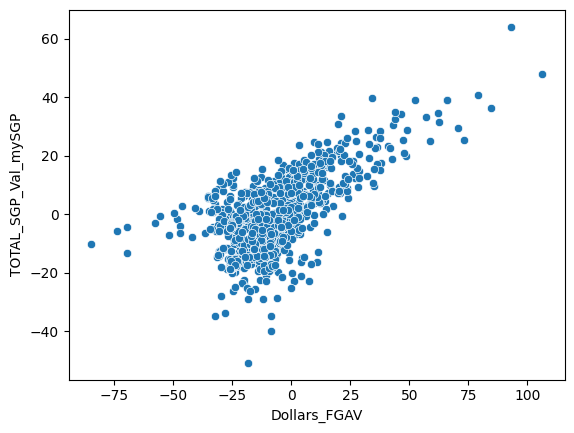

In [35]:
import seaborn as sns
sns.scatterplot(Full_Merge_df,x='Dollars_FGAV',y='TOTAL_SGP_Val_mySGP')

In [36]:
Full_Merge_df['Ottoneu ID']

0       18048
1        4970
2        6225
3        6305
4        5098
        ...  
2953    32579
2954    32716
2955    33058
2956    37530
2957    33510
Name: Ottoneu ID, Length: 2958, dtype: str

In [37]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isin([key for key, val in Full_Merge_df['Ottoneu ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,MLBAMID,Name,Team,NameASCII,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,...,mHR_FGAV,mOBP_FGAV,mSLG_FGAV,PTS_FGAV,aPOS_FGAV,Dollars_FGAV,IP_FGAV,mERA_FGAV,mWHIP_FGAV,mSO_FGAV


In [38]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isna()]

,FG ID,MLBAMID,Name,Team,NameASCII,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,...,mHR_FGAV,mOBP_FGAV,mSLG_FGAV,PTS_FGAV,aPOS_FGAV,Dollars_FGAV,IP_FGAV,mERA_FGAV,mWHIP_FGAV,mSO_FGAV


# Vibbot ATC

In [39]:
Vibbot_ATC_df = pd.read_csv(League_Proj_files['Vibbot'])
Vibbot_ATC_df.rename(columns={'otto':'Ottoneu ID','$':'Dollars_Vibbot'},inplace=True)

In [40]:
Vibbot_ATC_df.dropna(subset=['Ottoneu ID'],inplace=True)

In [41]:
Vibbot_ATC_df['Ottoneu ID'] = Vibbot_ATC_df['Ottoneu ID'].astype(str)
Vibbot_ATC_df['Ottoneu ID'] = Vibbot_ATC_df['Ottoneu ID'].str.replace('.0','')

In [42]:
Vibbot_ATC_df.head()

,Ottoneu ID,Name,Team,Pos,Dollars_Vibbot
0,33600,Shohei Ohtani,LAD,Util,80.4
1,18312,Aaron Judge,NYY,OF,68.9
2,23717,Juan Soto,NYM,OF,56.8
3,43894,Paul Skenes,PIT,SP,54.8
4,35204,Tarik Skubal,DET,SP,54.2


In [43]:
Vibbot_ATC_df = Vibbot_ATC_df[['Ottoneu ID','Dollars_Vibbot']].merge(Player_ID_Map_df[['FG ID','Ottoneu ID','Ottoneu Positions','Name']],how='left')

In [44]:
Vibbot_ATC_df.columns

Index(['Ottoneu ID', 'Dollars_Vibbot', 'FG ID', 'Ottoneu Positions', 'Name'], dtype='str')

In [45]:
Vibbot_ATC_df.head()

,Ottoneu ID,Dollars_Vibbot,FG ID,Ottoneu Positions,Name
0,33600,80.4,19755,Util/SP,Shohei Ohtani
1,18312,68.9,15640,OF,Aaron Judge
2,23717,56.8,20123,OF,Juan Soto
3,43894,54.8,33677,SP,Paul Skenes
4,35204,54.2,22267,SP,Tarik Skubal


In [46]:
Full_Merge_df = Full_Merge_df.merge(Vibbot_ATC_df,how='outer')

In [47]:
Full_Merge_df.shape

(2958, 84)

In [48]:
Full_Merge_df.head()

,FG ID,MLBAMID,Name,Team,NameASCII,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,...,mOBP_FGAV,mSLG_FGAV,PTS_FGAV,aPOS_FGAV,Dollars_FGAV,IP_FGAV,mERA_FGAV,mWHIP_FGAV,mSO_FGAV,Dollars_Vibbot
0,10028,542194,Christian Bethancourt,CHC,Christian Bethancourt,0.00,1.00,1.00,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10061,548384,Brooks Raley,NYM,Brooks Raley,60.70,NaN,NaN,50.97,NaN,...,NaN,NaN,-9.29,4.12,-4.17,62.0,-3.32,-4.81,-4.35,NaN
2,10078,573204,Caleb Thielbar,CHC,Caleb Thielbar,65.71,NaN,NaN,54.64,NaN,...,NaN,NaN,-5.10,4.12,0.01,66.0,-1.81,-2.20,-3.39,NaN
3,10155,545361,Mike Trout,LAA,Mike Trout,129.14,556.38,472.47,113.94,65.56,...,1.26,-0.85,-6.75,19.40,13.65,NaN,NaN,NaN,NaN,20.6
4,10231,578428,Jose Iglesias,NaN,Jose Iglesias,NaN,NaN,NaN,NaN,NaN,...,-2.27,-5.12,-45.44,19.18,-25.26,NaN,NaN,NaN,NaN,NaN


In [49]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isin([key for key, val in Full_Merge_df['Ottoneu ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,MLBAMID,Name,Team,NameASCII,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,...,mOBP_FGAV,mSLG_FGAV,PTS_FGAV,aPOS_FGAV,Dollars_FGAV,IP_FGAV,mERA_FGAV,mWHIP_FGAV,mSO_FGAV,Dollars_Vibbot


In [50]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isna()]

,FG ID,MLBAMID,Name,Team,NameASCII,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,...,mOBP_FGAV,mSLG_FGAV,PTS_FGAV,aPOS_FGAV,Dollars_FGAV,IP_FGAV,mERA_FGAV,mWHIP_FGAV,mSO_FGAV,Dollars_Vibbot


<Axes: xlabel='Dollars_Vibbot', ylabel='TOTAL_SGP_Val_mySGP'>

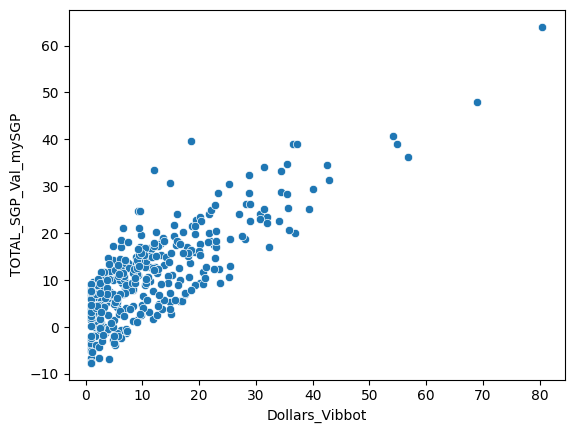

In [51]:
sns.scatterplot(Full_Merge_df,x='Dollars_Vibbot',y='TOTAL_SGP_Val_mySGP')

<Axes: xlabel='Dollars_Vibbot', ylabel='Dollars_FGAV'>

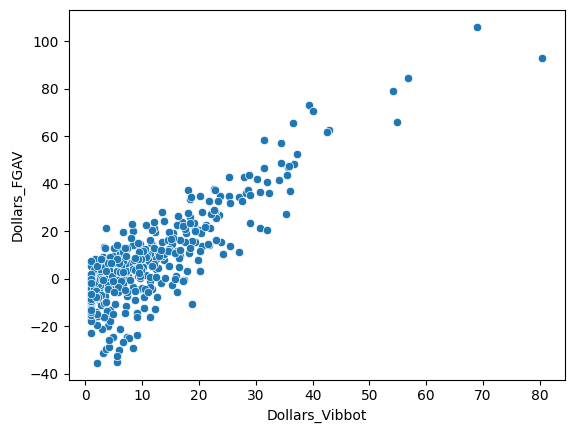

In [52]:
sns.scatterplot(Full_Merge_df,x='Dollars_Vibbot',y='Dollars_FGAV')

# Ottoneu 4x4

In [53]:
Ottoneu_Average_df = pd.read_csv(League_Proj_files['Ottoneu']).drop(columns='Unnamed: 0')

In [54]:
for col in ['Avg Salary','Median Salary','Min Salary','Max Salary','Last 10']:
    Ottoneu_Average_df[col] = Ottoneu_Average_df[col].str.strip('$').astype(float)

In [55]:
Ottoneu_Average_df = Ottoneu_Average_df.rename(
        columns={
            'OttoneuID':'Ottoneu ID',
            'Position(s)':'Ottoneu Positions',
            'Avg Salary':'Ottoneu_Avg',
            'Median Salary':'Ottoneu_Med',
            'Min Salary':'Ottoneu_Min',
            'Max Salary':'Ottoneu_Max',
            'Last 10':'Ottoneu_L10',
        }
    )

In [56]:
Ottoneu_Average_df['Ottoneu ID'] = Ottoneu_Average_df['Ottoneu ID'].astype(str)
Ottoneu_Average_df['Ottoneu ID'] = Ottoneu_Average_df['Ottoneu ID'].str.replace('.0','')

In [57]:
Ottoneu_Average_df = Ottoneu_Average_df[[
    'Ottoneu ID',
    'Ottoneu_Avg',
    'Ottoneu_Med',
    'Ottoneu_Min',
    'Ottoneu_Max',
    'Ottoneu_L10',
    'Roster%'
]].merge(Player_ID_Map_df[['FG ID','Ottoneu ID','Ottoneu Positions','Name']],how='left')

In [58]:
Ottoneu_Average_df.shape

(871, 10)

In [59]:
Ottoneu_Average_df.head()

,Ottoneu ID,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Ottoneu_L10,Roster%,FG ID,Ottoneu Positions,Name
0,33600,77.33,77.5,60.0,89.0,61.0,100.00,19755,Util/SP,Shohei Ohtani
1,18312,71.50,71.0,54.0,85.0,49.9,100.00,15640,OF,Aaron Judge
2,23717,69.48,70.0,59.0,81.0,69.9,95.83,20123,OF,Juan Soto
3,18276,57.31,60.5,33.0,68.0,49.5,66.67,13611,SS,Mookie Betts
4,23795,52.00,51.0,25.0,68.0,42.1,83.33,19556,OF,Yordan Alvarez


In [60]:
Ottoneu_Average_df.columns

Index(['Ottoneu ID', 'Ottoneu_Avg', 'Ottoneu_Med', 'Ottoneu_Min',
       'Ottoneu_Max', 'Ottoneu_L10', 'Roster%', 'FG ID', 'Ottoneu Positions',
       'Name'],
      dtype='str')

In [61]:
Full_Merge_df = Full_Merge_df.merge(Ottoneu_Average_df,how='outer')

<Axes: xlabel='Ottoneu_Avg', ylabel='TOTAL_SGP_Val_mySGP'>

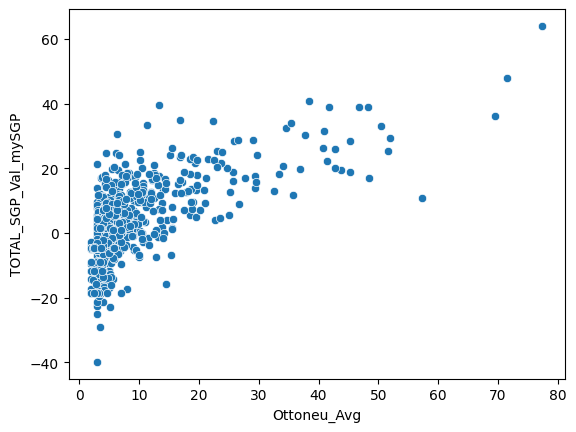

In [62]:
sns.scatterplot(Full_Merge_df,x='Ottoneu_Avg',y='TOTAL_SGP_Val_mySGP')

<Axes: xlabel='Ottoneu_Avg', ylabel='Dollars_FGAV'>

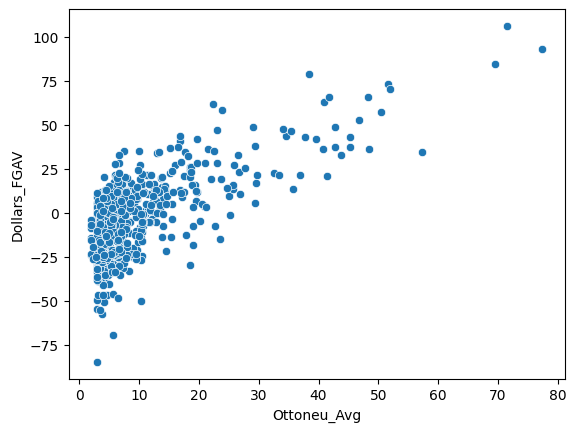

In [63]:
sns.scatterplot(Full_Merge_df,x='Ottoneu_Avg',y='Dollars_FGAV')

<Axes: xlabel='Ottoneu_Avg', ylabel='Dollars_Vibbot'>

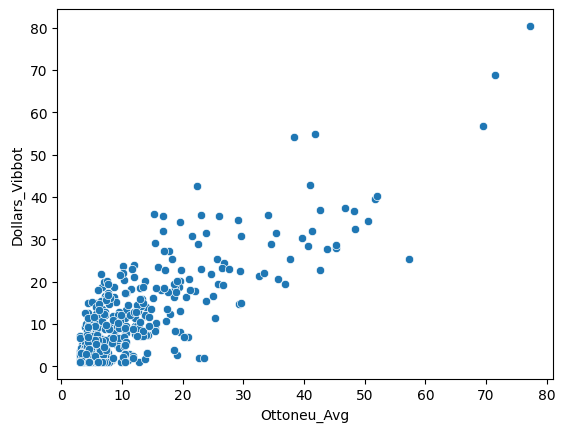

In [64]:
sns.scatterplot(Full_Merge_df,x='Ottoneu_Avg',y='Dollars_Vibbot')

In [65]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isin([key for key, val in Full_Merge_df['Ottoneu ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,MLBAMID,Name,Team,NameASCII,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,...,mERA_FGAV,mWHIP_FGAV,mSO_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Ottoneu_L10,Roster%


In [66]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isna()]

,FG ID,MLBAMID,Name,Team,NameASCII,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,...,mERA_FGAV,mWHIP_FGAV,mSO_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Ottoneu_L10,Roster%


# League Rosters

In [67]:
League_Rosters_df = pd.read_csv(League_Proj_files['Rosters']).drop(columns='Unnamed: 0')


In [68]:
League_Rosters_df.head()

,TeamID,Team Name,ottoneu ID,FG MajorLeagueID,FG MinorLeagueID,Name,MLB Team,Position(s),Salary
0,55,Jack Klugman's Second Best Lung,39108,28163.0,sa3015532,Junior Caminero,TBR,3B,34
1,55,Jack Klugman's Second Best Lung,40927,30116.0,sa3018052,Seiya Suzuki,CHC,OF,33
2,55,Jack Klugman's Second Best Lung,37094,27676.0,sa1115762,Vinnie Pasquantino,KCR,1B,17
3,55,Jack Klugman's Second Best Lung,46310,35466.0,sa3043900,Payton Tolle,BOS,SP/RP,15
4,55,Jack Klugman's Second Best Lung,36922,25768.0,sa3010152,CJ Abrams,WSN,SS,14


In [69]:
League_Rosters_df = League_Rosters_df.rename(
        columns={
            'ottoneu ID':'Ottoneu ID',
            'Position(s)':'Ottoneu Positions'
        }
    )

In [70]:
League_Rosters_df['Ottoneu ID'] = League_Rosters_df['Ottoneu ID'].astype(str)
League_Rosters_df['Ottoneu ID'] = League_Rosters_df['Ottoneu ID'].str.replace('.0','')

In [71]:
League_Rosters_df = League_Rosters_df[['TeamID','Team Name','Ottoneu ID','Salary']].merge(Player_ID_Map_df[['FG ID','Ottoneu ID','Ottoneu Positions','Name']],how='left')

In [72]:
Full_Merge_df.columns

Index(['FG ID', 'MLBAMID', 'Name', 'Team', 'NameASCII', 'G_mySGP', 'PA_mySGP',
       'AB_mySGP', 'H_mySGP', '1B_mySGP', '2B_mySGP', '3B_mySGP', 'HR_mySGP',
       'R_mySGP', 'RBI_mySGP', 'BB_mySGP', 'HBP_mySGP', 'SF_mySGP',
       'WAR_mySGP', 'ADP_mySGP', 'POS_mySGP', 'OBP_mySGP', 'TB_mySGP',
       'SLG_mySGP', 'Pos Place_mySGP', 'R_SGP_raw_mySGP', 'HR_SGP_raw_mySGP',
       'OBP_SGP_raw_mySGP', 'SLG_SGP_raw_mySGP', 'TOTAL_SGP_raw_mySGP',
       'R_SGP_norm_mySGP', 'HR_SGP_norm_mySGP', 'OBP_SGP_norm_mySGP',
       'SLG_SGP_norm_mySGP', 'TOTAL_SGP_mySGP', 'TOTAL_SGP_Rank_mySGP',
       'TOTAL_SGP_Val_mySGP', 'R_SGP_Val_mySGP', 'HR_SGP_Val_mySGP',
       'OBP_SGP_Val_mySGP', 'SLG_SGP_Val_mySGP', 'Ottoneu ID',
       'Ottoneu Positions', 'W_mySGP', 'L_mySGP', 'QS_mySGP', 'GS_mySGP',
       'SV_mySGP', 'HLD_mySGP', 'IP_mySGP', 'TBF_mySGP', 'ER_mySGP',
       'SO_mySGP', 'K_mySGP', 'HR9_mySGP', 'ERA_mySGP', 'WHIP_mySGP',
       'K_SGP_raw_mySGP', 'HR9_SGP_raw_mySGP', 'ERA_SGP_raw_mySGP',

In [73]:
League_Rosters_df.columns

Index(['TeamID', 'Team Name', 'Ottoneu ID', 'Salary', 'FG ID',
       'Ottoneu Positions', 'Name'],
      dtype='str')

In [74]:
Full_Merge_df = Full_Merge_df.merge(League_Rosters_df,how='outer')

In [75]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isin([key for key, val in Full_Merge_df['Ottoneu ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,MLBAMID,Name,Team,NameASCII,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,...,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Ottoneu_L10,Roster%,TeamID,Team Name,Salary


In [76]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isna()]

,FG ID,MLBAMID,Name,Team,NameASCII,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,...,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Ottoneu_L10,Roster%,TeamID,Team Name,Salary


# Total Value Replacement Level

In [77]:
Full_Merge_df.columns

Index(['FG ID', 'MLBAMID', 'Name', 'Team', 'NameASCII', 'G_mySGP', 'PA_mySGP',
       'AB_mySGP', 'H_mySGP', '1B_mySGP', '2B_mySGP', '3B_mySGP', 'HR_mySGP',
       'R_mySGP', 'RBI_mySGP', 'BB_mySGP', 'HBP_mySGP', 'SF_mySGP',
       'WAR_mySGP', 'ADP_mySGP', 'POS_mySGP', 'OBP_mySGP', 'TB_mySGP',
       'SLG_mySGP', 'Pos Place_mySGP', 'R_SGP_raw_mySGP', 'HR_SGP_raw_mySGP',
       'OBP_SGP_raw_mySGP', 'SLG_SGP_raw_mySGP', 'TOTAL_SGP_raw_mySGP',
       'R_SGP_norm_mySGP', 'HR_SGP_norm_mySGP', 'OBP_SGP_norm_mySGP',
       'SLG_SGP_norm_mySGP', 'TOTAL_SGP_mySGP', 'TOTAL_SGP_Rank_mySGP',
       'TOTAL_SGP_Val_mySGP', 'R_SGP_Val_mySGP', 'HR_SGP_Val_mySGP',
       'OBP_SGP_Val_mySGP', 'SLG_SGP_Val_mySGP', 'Ottoneu ID',
       'Ottoneu Positions', 'W_mySGP', 'L_mySGP', 'QS_mySGP', 'GS_mySGP',
       'SV_mySGP', 'HLD_mySGP', 'IP_mySGP', 'TBF_mySGP', 'ER_mySGP',
       'SO_mySGP', 'K_mySGP', 'HR9_mySGP', 'ERA_mySGP', 'WHIP_mySGP',
       'K_SGP_raw_mySGP', 'HR9_SGP_raw_mySGP', 'ERA_SGP_raw_mySGP',

In [78]:
Full_Merge_df[['FG ID',    'Name',
    'Team',
    'Ottoneu Positions',
    'Ottoneu ID',
    'ADP_FGAV',
    'TOTAL_SGP_Val_mySGP',
    'Dollars_FGAV',
    'Dollars_Vibbot',
    'Ottoneu_Avg',
    'Ottoneu_Med', 
    'Ottoneu_Min', 
    'Ottoneu_Max',
    'Salary']].sort_values(by=['ADP_FGAV']).tail(150)

,FG ID,Name,Team,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary
2854,sa3043560,Devin Taylor,ATH,Util,47883,NaN,-18.69,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2855,sa3043596,Kavares Tears,SDP,OF,46306,NaN,-18.69,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2856,sa3043664,Cardell Thibodeaux,SDP,OF,47886,NaN,-18.69,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2857,sa3043700,Justin Thomas,HOU,Util,47887,NaN,-18.69,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2858,sa3044088,Camden Troyer,NYY,OF,47893,NaN,-18.69,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3006,sa918182,Julian Garcia,CIN,Util,32716,NaN,-5.28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3008,sa918983,Matt Fraizer,BOS,OF,37530,NaN,-18.69,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3009,sa944989,Daison Acosta,SDP,RP,33510,NaN,-2.64,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3010,NaN,JoJo Parker,NaN,Util,47541,NaN,NaN,NaN,NaN,3.0,3.0,3.0,3.0,NaN


In [79]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isin([key for key, val in Full_Merge_df['Ottoneu ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,MLBAMID,Name,Team,NameASCII,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,...,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Ottoneu_L10,Roster%,TeamID,Team Name,Salary


In [80]:
Full_Merge_df[Full_Merge_df['Name'].isna()][['FG ID','Ottoneu ID','Name']]

,FG ID,Ottoneu ID,Name


In [81]:
Full_Merge_df.columns

Index(['FG ID', 'MLBAMID', 'Name', 'Team', 'NameASCII', 'G_mySGP', 'PA_mySGP',
       'AB_mySGP', 'H_mySGP', '1B_mySGP', '2B_mySGP', '3B_mySGP', 'HR_mySGP',
       'R_mySGP', 'RBI_mySGP', 'BB_mySGP', 'HBP_mySGP', 'SF_mySGP',
       'WAR_mySGP', 'ADP_mySGP', 'POS_mySGP', 'OBP_mySGP', 'TB_mySGP',
       'SLG_mySGP', 'Pos Place_mySGP', 'R_SGP_raw_mySGP', 'HR_SGP_raw_mySGP',
       'OBP_SGP_raw_mySGP', 'SLG_SGP_raw_mySGP', 'TOTAL_SGP_raw_mySGP',
       'R_SGP_norm_mySGP', 'HR_SGP_norm_mySGP', 'OBP_SGP_norm_mySGP',
       'SLG_SGP_norm_mySGP', 'TOTAL_SGP_mySGP', 'TOTAL_SGP_Rank_mySGP',
       'TOTAL_SGP_Val_mySGP', 'R_SGP_Val_mySGP', 'HR_SGP_Val_mySGP',
       'OBP_SGP_Val_mySGP', 'SLG_SGP_Val_mySGP', 'Ottoneu ID',
       'Ottoneu Positions', 'W_mySGP', 'L_mySGP', 'QS_mySGP', 'GS_mySGP',
       'SV_mySGP', 'HLD_mySGP', 'IP_mySGP', 'TBF_mySGP', 'ER_mySGP',
       'SO_mySGP', 'K_mySGP', 'HR9_mySGP', 'ERA_mySGP', 'WHIP_mySGP',
       'K_SGP_raw_mySGP', 'HR9_SGP_raw_mySGP', 'ERA_SGP_raw_mySGP',

In [82]:
Full_Merge_sorted_df = Full_Merge_df[[
    'Name',
    'Team',
    'TeamID',
    'Team Name',
    'Ottoneu Positions',
    'Ottoneu ID',
    'ADP_FGAV',
    'TOTAL_SGP_Val_mySGP',
    'Dollars_FGAV',
    'Dollars_Vibbot',
    'Ottoneu_Avg',
    'Ottoneu_Med', 
    'Ottoneu_Min', 
    'Ottoneu_Max',
    'Salary'
]].sort_values(by=['ADP_FGAV'])

In [83]:
# sns.pairplot(Full_Merge_sorted_df[ \
#     (Full_Merge_sorted_df['ADP_FGAV'] <= 500) | \
#     (Full_Merge_sorted_df['TOTAL_SGP_Val_mySGP'] > 0.) | \
#     (Full_Merge_sorted_df['Dollars_FGAV'] > 0.) | \
#     (Full_Merge_sorted_df['Dollars_Vibbot'] > 0.) | \
#     (Full_Merge_sorted_df['Ottoneu_Avg'] > 0.) | \
#     (Full_Merge_sorted_df['Ottoneu_Med'] > 0.) | \
#     (Full_Merge_sorted_df['Salary'] > 0.)][[
#     'Name',
#     'Team',
#     'Ottoneu Positions',
#     'ADP_FGAV',
#     'TOTAL_SGP_Val_mySGP',
#     'Dollars_FGAV',
#     'Dollars_Vibbot',
#     'Ottoneu_Avg',
#     'Ottoneu_Med', 
#     'Ottoneu_Min', 
#     'Ottoneu_Max',
#     'Salary'
# ]])

In [84]:
Full_Merge_sorted_df

,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary
482,Shohei Ohtani,LAD,154.0,The Rime of Jamie Moyer,Util/SP,33600,1.11,64.00,92.96,80.4,77.33,77.5,60.0,89.0,75.0
193,Aaron Judge,NYY,197.0,St. CGT VI,OF,18312,1.97,47.97,106.14,68.9,71.50,71.0,54.0,85.0,73.0
926,Bobby Witt Jr.,KCR,236.0,Yoshi Teddy Bear,SS,36668,3.28,38.96,52.55,37.3,46.71,46.5,24.0,68.0,48.0
548,Juan Soto,NYM,197.0,St. CGT VI,OF,23717,4.47,36.30,84.64,56.8,69.48,70.0,59.0,81.0,64.0
99,José Ramírez,CLE,112.0,Hornswogglers,3B,18284,5.31,17.03,36.09,32.3,48.45,47.0,38.0,60.0,57.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3006,Julian Garcia,CIN,NaN,NaN,Util,32716,NaN,-5.28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3008,Matt Fraizer,BOS,NaN,NaN,OF,37530,NaN,-18.69,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3009,Daison Acosta,SDP,NaN,NaN,RP,33510,NaN,-2.64,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3010,JoJo Parker,NaN,NaN,NaN,Util,47541,NaN,NaN,NaN,NaN,3.00,3.0,3.0,3.0,NaN


In [85]:
quick_plot = Full_Merge_sorted_df[ \
    (Full_Merge_sorted_df['ADP_FGAV'] <= 50) ]#| \
    # (Full_Merge_sorted_df['TOTAL_SGP_Val_mySGP'] > 0.) | \
    # (Full_Merge_sorted_df['Dollars_FGAV'] > 0.) | \
    # (Full_Merge_sorted_df['Dollars_Vibbot'] > 0.) | \
    # (Full_Merge_sorted_df['Ottoneu_Avg'] > 0.) | \
    # (Full_Merge_sorted_df['Ottoneu_Med'] > 0.) | \
    # (Full_Merge_sorted_df['Salary'] > 0.)]

In [86]:
def quick_plotting_fn(quick_plot,ax1):
    ax1.errorbar(
        y=quick_plot['Name'],
        x=quick_plot['Ottoneu_Avg'],
        xerr=[
            quick_plot['Ottoneu_Avg']-quick_plot['Ottoneu_Min'],
            quick_plot['Ottoneu_Max']-quick_plot['Ottoneu_Avg']
        ],
        fmt='o',
        color='blue',
        label='4x4 Avg, Min, Max'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Ottoneu_Med'],
        marker='^',
        color='black',
        label='4x4 Median'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Salary'],
        marker='$\\$$',
        s=150,
        color='red',
        label='Current Salary'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Dollars_FGAV'],
        marker='$FG$',
        s=150,
        color='green',
        label='FG Auction Calc.'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Dollars_Vibbot'],
        marker='+',
        s=100,
        color='tab:brown',
        label='Secret Sauce V'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['TOTAL_SGP_Val_mySGP'],
        marker='*',
        s=100,
        color='tab:pink',
        label='Secret Sauce C'
    )
    ax1.set_ylabel('Player')
    ax1.invert_yaxis()
    ax1.set_xlabel('Dollars')
    ax1.legend(loc='lower right')
    ax1.tick_params(axis='y', which='major', labelsize=7)
    return

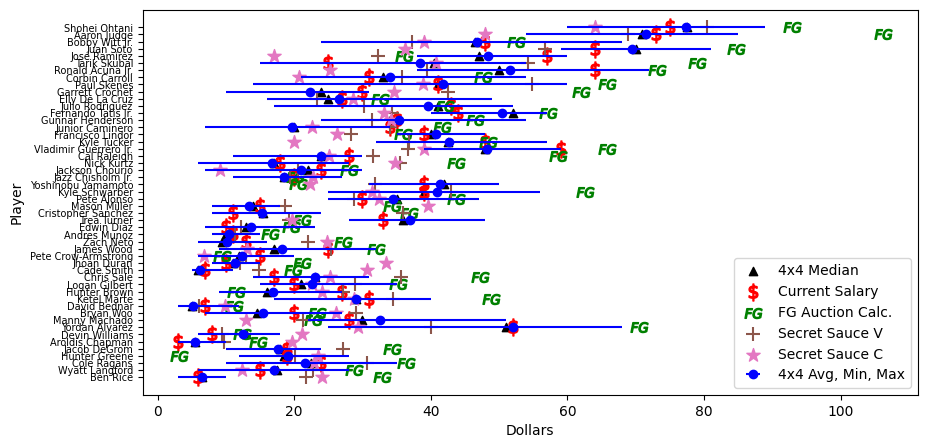

In [87]:
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(111)
quick_plotting_fn(quick_plot,ax1)
plt.show()

In [88]:
Full_Merge_sorted_df.columns

Index(['Name', 'Team', 'TeamID', 'Team Name', 'Ottoneu Positions',
       'Ottoneu ID', 'ADP_FGAV', 'TOTAL_SGP_Val_mySGP', 'Dollars_FGAV',
       'Dollars_Vibbot', 'Ottoneu_Avg', 'Ottoneu_Med', 'Ottoneu_Min',
       'Ottoneu_Max', 'Salary'],
      dtype='str')

In [89]:
Full_Merge_sorted_df[Full_Merge_sorted_df['Ottoneu Positions'].isin(['SP','RP','SP/RP','Util/SP'])]['ADP_FGAV'].rank()

482     1.0
718     2.0
1371    3.0
1033    4.0
1377    5.0
       ... 
2800    NaN
2802    NaN
2849    NaN
2945    NaN
3009    NaN
Name: ADP_FGAV, Length: 878, dtype: float64

###################################
Position C Replacement Level = 24
###################################
Replacement Level ADP_FGAV C 284.10 +- 34.64


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_C_rank
333,Tyler Stephenson,CIN,NaN,NaN,C,22654,247.28,3.54e+00,1.10,1.7,8.33,7.0,4.0,14.0,NaN,22.0
842,Ryan Jeffers,MIN,NaN,NaN,C,33652,249.31,6.39e+00,14.14,5.5,4.93,5.0,3.0,11.0,NaN,23.0
477,Carlos Narvaez,NaN,NaN,NaN,C,32084,289.33,NaN,-1.50,NaN,3.83,3.0,3.0,6.0,NaN,24.0
108,Carson Kelly,CHC,NaN,NaN,C,23714,315.78,-1.16e+00,-0.41,NaN,4.08,3.0,3.0,8.0,NaN,25.0
1134,Edgar Quero,CHW,NaN,NaN,C,38887,318.78,4.57e-03,0.21,NaN,3.33,3.0,3.0,4.0,NaN,26.0


ADP_FGAV 284.09599609375  +-  34.64005657163275
Replacement Level TOTAL_SGP_Val_mySGP C 0.60 +- 0.83


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_C_rank,TOTAL_SGP_Val_mySGP_C_rank
1198,Liam Hicks,MIA,NaN,NaN,C/1B,40541,494.78,-3.62e-01,-10.96,NaN,NaN,NaN,NaN,NaN,NaN,40.0,26.0
1134,Edgar Quero,CHW,NaN,NaN,C,38887,318.78,4.57e-03,0.21,NaN,3.33,3.0,3.0,4.0,NaN,26.0,25.0
1034,Dillon Dingler,DET,NaN,NaN,C,38308,219.64,4.51e-01,-2.52,NaN,3.73,4.0,3.0,6.0,NaN,19.0,24.0
426,Sean Murphy,ATL,185.0,Chili Dog MVP,C,31687,399.56,1.43e+00,1.00,1.0,6.79,7.0,3.0,13.0,4.0,32.0,23.0
1149,Carter Jensen,KCR,240.0,Largely Indistinguishables,C,40505,999.00,1.47e+00,1.72,NaN,5.33,5.0,3.0,9.0,9.0,68.0,22.0


TOTAL_SGP_Val_mySGP 0.5988470086122321  +-  0.8289673014694847
Replacement Level Dollars_FGAV C 0.99 +- 0.54


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_C_rank,TOTAL_SGP_Val_mySGP_C_rank,Dollars_FGAV_C_rank
1134,Edgar Quero,CHW,NaN,NaN,C,38887,318.78,4.57e-03,0.21,NaN,3.33,3.0,3.0,4.0,NaN,26.0,25.0,26.0
244,Danny Jansen,TEX,NaN,NaN,C,19481,446.00,-1.62e+00,0.94,NaN,11.00,11.0,11.0,11.0,NaN,35.0,29.0,25.0
426,Sean Murphy,ATL,185.0,Chili Dog MVP,C,31687,399.56,1.43e+00,1.00,1.0,6.79,7.0,3.0,13.0,4.0,32.0,23.0,24.0
333,Tyler Stephenson,CIN,NaN,NaN,C,22654,247.28,3.54e+00,1.10,1.7,8.33,7.0,4.0,14.0,NaN,22.0,17.0,23.0
1149,Carter Jensen,KCR,240.0,Largely Indistinguishables,C,40505,999.00,1.47e+00,1.72,NaN,5.33,5.0,3.0,9.0,9.0,68.0,22.0,22.0


Dollars_FGAV 0.9947779371988344  +-  0.5377282378213162
Dollars_Vibbot nan  +-  nan


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_13070/1875085877.py:110: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


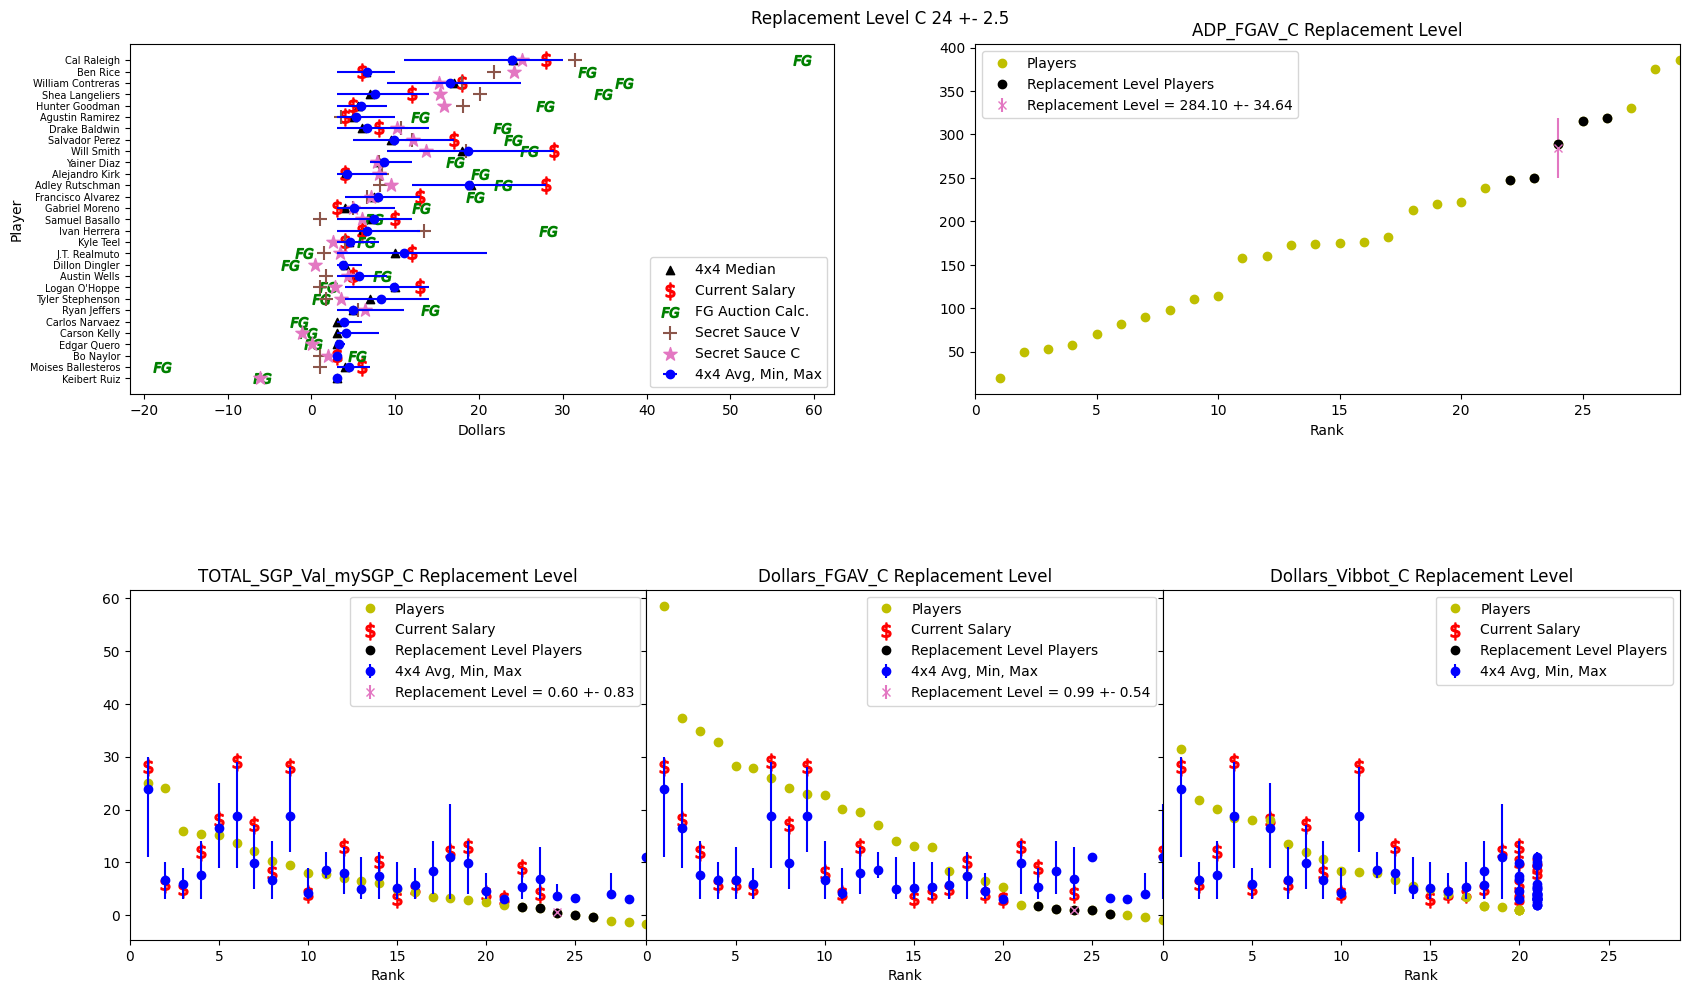

###################################
Position 1B Replacement Level = 25
###################################
Replacement Level ADP_FGAV 1B 263.90 +- 16.20


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_1B_rank
1191,Kyle Manzardo,CLE,247.0,Roberto Big Piece and the 69ers,1B,40508,238.19,17.89,6.00,12.0,7.21,7.0,4.0,11.0,6.0,23.0
995,Spencer Steer,CIN,NaN,NaN,1B/OF,37216,257.69,14.37,11.14,9.4,10.69,10.5,6.0,20.0,NaN,24.0
236,Ryan O'Hearn,PIT,197.0,St. CGT VI,1B/OF,21156,272.83,14.96,4.71,9.1,5.57,5.0,3.0,10.0,5.0,25.0
656,Alec Bohm,PHI,240.0,Largely Indistinguishables,1B/3B,33609,273.61,3.76,-0.58,7.9,10.73,11.0,3.0,15.0,15.0,26.0
720,Jake Burger,TEX,185.0,Chili Dog MVP,1B,23809,277.17,18.59,5.26,6.3,8.36,7.0,3.0,19.0,7.0,27.0


ADP_FGAV 263.897998046875  +-  16.19945798616584
Replacement Level TOTAL_SGP_Val_mySGP 1B 12.81 +- 0.79


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_1B_rank,TOTAL_SGP_Val_mySGP_1B_rank
1420,Salvador Perez,KCR,236.0,Yoshi Teddy Bear,C/1B,8626,97.64,12.12,24.07,12.0,9.83,9.5,5.0,17.0,17.0,11.0,27.0
339,Jake Cronenworth,SDP,197.0,St. CGT VI,1B/2B/SS,22004,405.86,12.21,-5.64,5.6,6.00,6.0,5.0,8.0,5.0,41.0,26.0
1124,Colt Keith,DET,90.0,Carlos Pérez's K-Dance,1B/2B/3B,38374,308.17,12.46,8.05,8.6,8.63,8.0,6.0,12.0,12.0,34.0,25.0
33,Willson Contreras,BOS,112.0,Hornswogglers,1B,12398,182.53,13.32,7.80,13.9,13.95,14.0,6.0,25.0,14.0,17.0,24.0
84,Josh Bell,MIN,NaN,NaN,1B,18152,334.39,13.94,3.82,7.2,3.00,3.0,3.0,3.0,NaN,35.0,23.0


TOTAL_SGP_Val_mySGP 12.809959085493526  +-  0.7895971661084067
Replacement Level Dollars_FGAV 1B 5.71 +- 0.65


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_1B_rank,TOTAL_SGP_Val_mySGP_1B_rank,Dollars_FGAV_1B_rank
1289,Sal Stewart,CIN,185.0,Chili Dog MVP,1B/3B,42358,214.69,14.91,5.12,11.7,5.38,4.5,3.0,13.0,13.0,21.0,19.0,27.0
720,Jake Burger,TEX,185.0,Chili Dog MVP,1B,23809,277.17,18.59,5.26,6.3,8.36,7.0,3.0,19.0,7.0,27.0,13.0,26.0
94,Christian Walker,HOU,253.0,Roar from 34,1B,18389,191.50,16.30,5.44,9.4,12.14,11.0,7.0,18.0,7.0,18.0,17.0,25.0
1191,Kyle Manzardo,CLE,247.0,Roberto Big Piece and the 69ers,1B,40508,238.19,17.89,6.00,12.0,7.21,7.0,4.0,11.0,6.0,23.0,14.0,24.0
1388,Jac Caglianone,KCR,241.0,🦫 Beavers in Scoring Position!,1B/OF,45720,227.89,0.89,6.70,4.5,7.00,7.0,3.0,11.0,10.0,22.0,47.0,23.0


Dollars_FGAV 5.7057017724662575  +-  0.6492941279675599
Replacement Level Dollars_Vibbot 1B 7.40 +- 0.88


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_1B_rank,TOTAL_SGP_Val_mySGP_1B_rank,Dollars_FGAV_1B_rank,Dollars_Vibbot_1B_rank
720,Jake Burger,TEX,185.0,Chili Dog MVP,1B,23809,277.17,18.59,5.26,6.3,8.36,7.0,3.0,19.0,7.0,27.0,13.0,26.0,27.0
1351,Nolan Schanuel,LAA,90.0,Carlos Pérez's K-Dance,1B,43932,303.64,14.22,12.91,7.0,4.44,4.0,3.0,8.0,6.0,33.0,22.0,16.0,26.0
84,Josh Bell,MIN,NaN,NaN,1B,18152,334.39,13.94,3.82,7.2,3.00,3.0,3.0,3.0,NaN,35.0,23.0,29.0,25.0
656,Alec Bohm,PHI,240.0,Largely Indistinguishables,1B/3B,33609,273.61,3.76,-0.58,7.9,10.73,11.0,3.0,15.0,15.0,26.0,39.0,33.0,24.0
1124,Colt Keith,DET,90.0,Carlos Pérez's K-Dance,1B/2B/3B,38374,308.17,12.46,8.05,8.6,8.63,8.0,6.0,12.0,12.0,34.0,25.0,20.0,23.0


Dollars_Vibbot 7.4  +-  0.8803408430829504


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_13070/1875085877.py:110: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


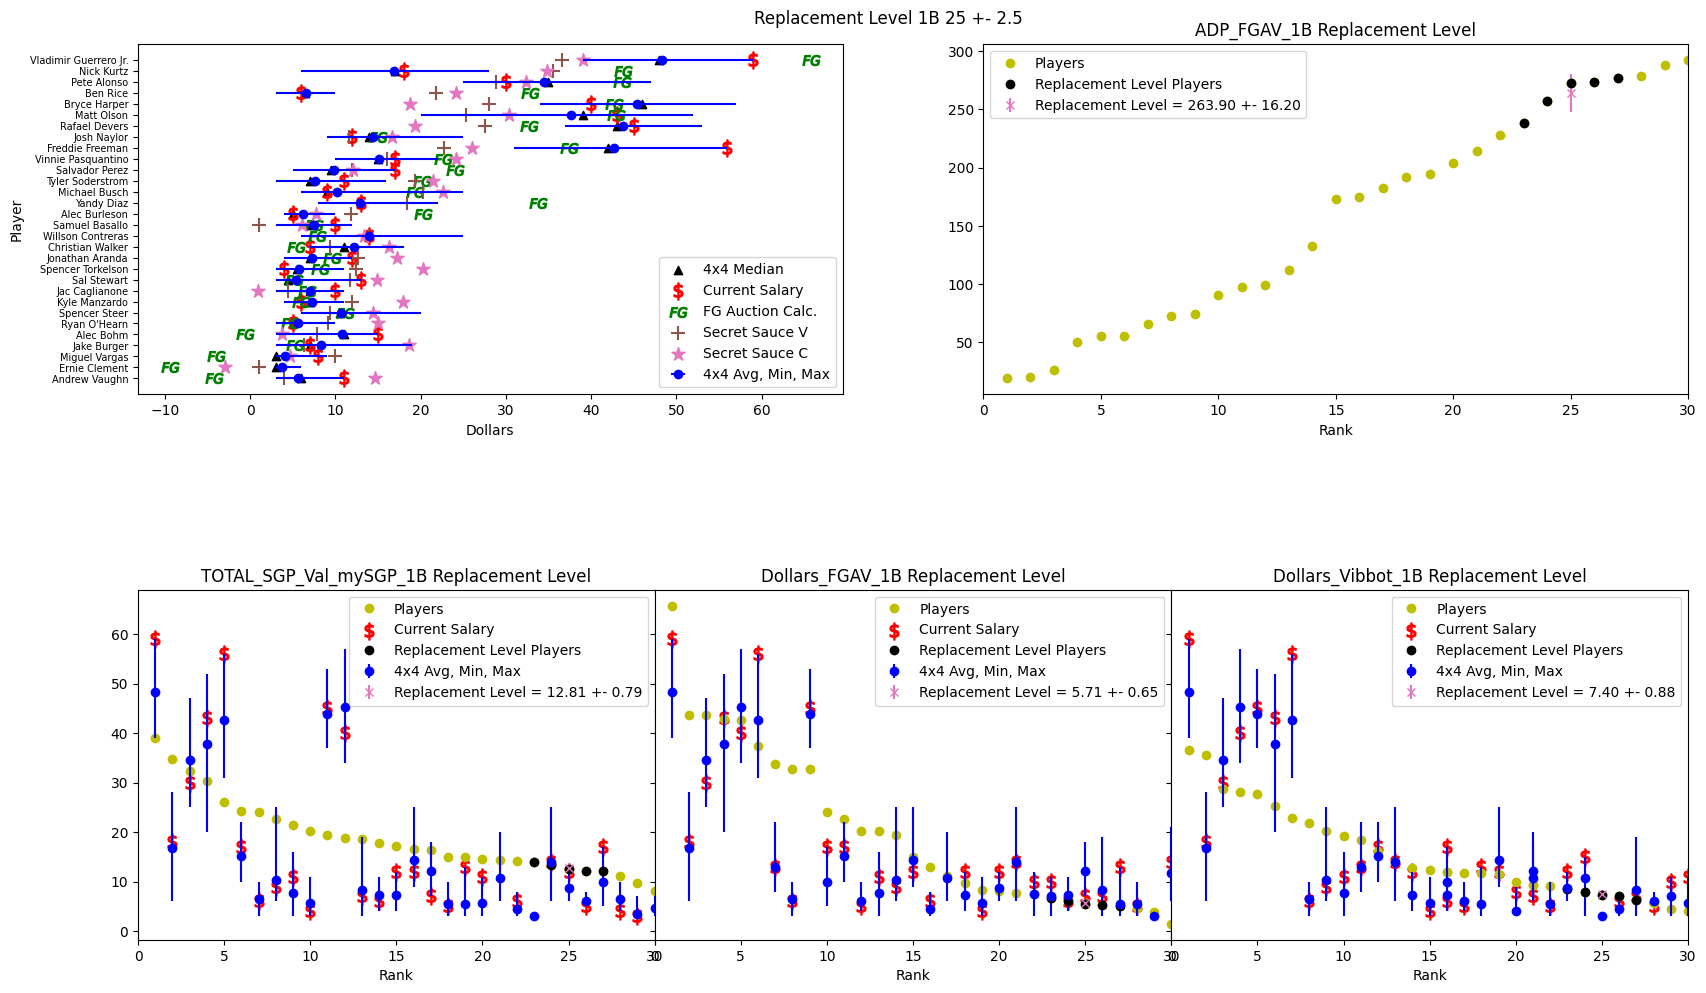

###################################
Position 2B Replacement Level = 27
###################################
Replacement Level ADP_FGAV 2B 291.18 +- 6.94


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_2B_rank
844,Brendan Donovan,STL,242.0,Smoak and Mirrors,2B/SS/OF,34619,281.33,14.13,9.31,10.7,9.65,10.0,6.0,13.0,10.0,25.0
567,Ernie Clement,TOR,NaN,NaN,1B/2B/SS/3B,31958,288.28,-2.99,-9.38,1.0,3.71,3.0,3.0,6.0,NaN,26.0
447,Tommy Edman,LAD,90.0,Carlos Pérez's K-Dance,2B/3B/OF,31703,293.06,6.17,-9.22,1.0,7.08,6.5,3.0,15.0,5.0,27.0
375,Luis Arraez,NaN,242.0,Smoak and Mirrors,1B/2B,20545,293.11,NaN,1.48,2.4,11.80,12.0,6.0,21.0,14.0,28.0
756,Lenyn Sosa,CHW,NaN,NaN,1B/2B,26411,300.11,3.73,-13.25,NaN,4.08,3.0,3.0,12.0,NaN,29.0


ADP_FGAV 291.17799072265626  +-  6.936076413890907
Replacement Level TOTAL_SGP_Val_mySGP 2B 7.51 +- 1.42


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_2B_rank,TOTAL_SGP_Val_mySGP_2B_rank
447,Tommy Edman,LAD,90.0,Carlos Pérez's K-Dance,2B/3B/OF,31703,293.06,6.17,-9.22,1.0,7.08,6.5,3.0,15.0,5.0,27.0,29.0
521,Gavin Lux,TBR,154.0,The Rime of Jamie Moyer,2B/3B/OF,32576,521.78,6.27,-13.96,NaN,5.75,5.5,3.0,10.0,5.0,59.0,28.0
1387,Christian Moore,LAA,112.0,Hornswogglers,2B,45708,417.33,7.07,-16.01,NaN,6.25,6.0,3.0,11.0,3.0,45.0,27.0
715,Nolan Gorman,STL,253.0,Roar from 34,2B/3B,33623,437.31,8.96,-2.09,2.1,5.14,6.0,3.0,7.0,3.0,49.0,26.0
1303,Brooks Lee,MIN,185.0,Chili Dog MVP,2B/SS/3B,42146,321.64,9.07,-7.07,NaN,5.48,6.0,3.0,9.0,7.0,32.0,25.0


TOTAL_SGP_Val_mySGP 7.506340026740887  +-  1.4184838981042969
Replacement Level Dollars_FGAV 2B -4.82 +- 0.72


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_2B_rank,TOTAL_SGP_Val_mySGP_2B_rank,Dollars_FGAV_2B_rank
339,Jake Cronenworth,SDP,197.0,St. CGT VI,1B/2B/SS,22004,405.86,12.21,-5.64,5.6,6.00,6.0,5.0,8.0,5.0,42.0,16.0,29.0
1181,Matt McLain,CIN,NaN,NaN,2B,40371,231.17,13.29,-5.55,5.8,10.69,10.5,6.0,16.0,NaN,18.0,13.0,28.0
285,Willi Castro,COL,197.0,St. CGT VI,2B/3B/OF,21708,365.00,-2.79,-4.53,4.8,6.08,5.0,5.0,11.0,7.0,36.0,71.0,27.0
964,Brett Baty,NYM,253.0,Roar from 34,2B/3B,37181,253.22,-0.25,-4.26,2.4,4.75,5.0,3.0,8.0,3.0,23.0,49.0,26.0
717,Xavier Edwards,MIA,112.0,Hornswogglers,2B/SS,33645,175.72,9.19,-4.12,1.0,6.11,5.0,3.0,12.0,5.0,11.0,24.0,25.0


Dollars_FGAV -4.819932577198432  +-  0.7232161694145328
Replacement Level Dollars_Vibbot 2B 1.39 +- 0.64


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_2B_rank,TOTAL_SGP_Val_mySGP_2B_rank,Dollars_FGAV_2B_rank,Dollars_Vibbot_2B_rank
717,Xavier Edwards,MIA,112.0,Hornswogglers,2B/SS,33645,175.72,9.19,-4.12,1.0,6.11,5.0,3.0,12.0,5.0,11.0,24.0,25.0,29.0
1178,Caleb Durbin,MIL,NaN,NaN,2B/3B,40398,232.00,-1.86,-6.44,1.0,3.30,3.0,3.0,6.0,NaN,19.0,59.0,30.0,29.0
1058,Ha-seong Kim,NaN,197.0,St. CGT VI,2B/SS,38127,260.58,NaN,-12.60,1.0,4.40,3.0,3.0,7.0,3.0,24.0,125.0,42.0,29.0
567,Ernie Clement,TOR,NaN,NaN,1B/2B/SS/3B,31958,288.28,-2.99,-9.38,1.0,3.71,3.0,3.0,6.0,NaN,26.0,73.0,38.0,29.0
447,Tommy Edman,LAD,90.0,Carlos Pérez's K-Dance,2B/3B/OF,31703,293.06,6.17,-9.22,1.0,7.08,6.5,3.0,15.0,5.0,27.0,29.0,36.0,29.0
1301,Chase Meidroth,CHW,NaN,NaN,2B/SS,42304,336.81,9.21,-1.64,1.0,4.44,3.0,3.0,11.0,NaN,33.0,23.0,18.0,29.0
1179,Marcelo Mayer,BOS,90.0,Carlos Pérez's K-Dance,2B/SS/3B,40095,371.67,0.19,-8.45,1.0,7.09,7.0,4.0,11.0,9.0,37.0,48.0,35.0,29.0
931,Jared Triolo,PIT,NaN,NaN,1B/2B/SS/3B,36984,404.53,-2.99,-13.46,1.0,3.00,3.0,3.0,3.0,NaN,41.0,74.0,45.0,29.0
734,Tyler Freeman,COL,NaN,NaN,2B/OF,26882,428.31,-7.62,-10.24,1.0,4.86,5.0,3.0,7.0,NaN,46.0,110.0,39.0,29.0
1070,Casey Schmitt,SFG,NaN,NaN,1B/2B/3B,38383,480.94,3.88,-16.60,1.0,3.00,3.0,3.0,3.0,NaN,53.0,36.0,52.0,29.0


Dollars_Vibbot 1.3933333333333333  +-  0.6430581696268305


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_13070/1875085877.py:110: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


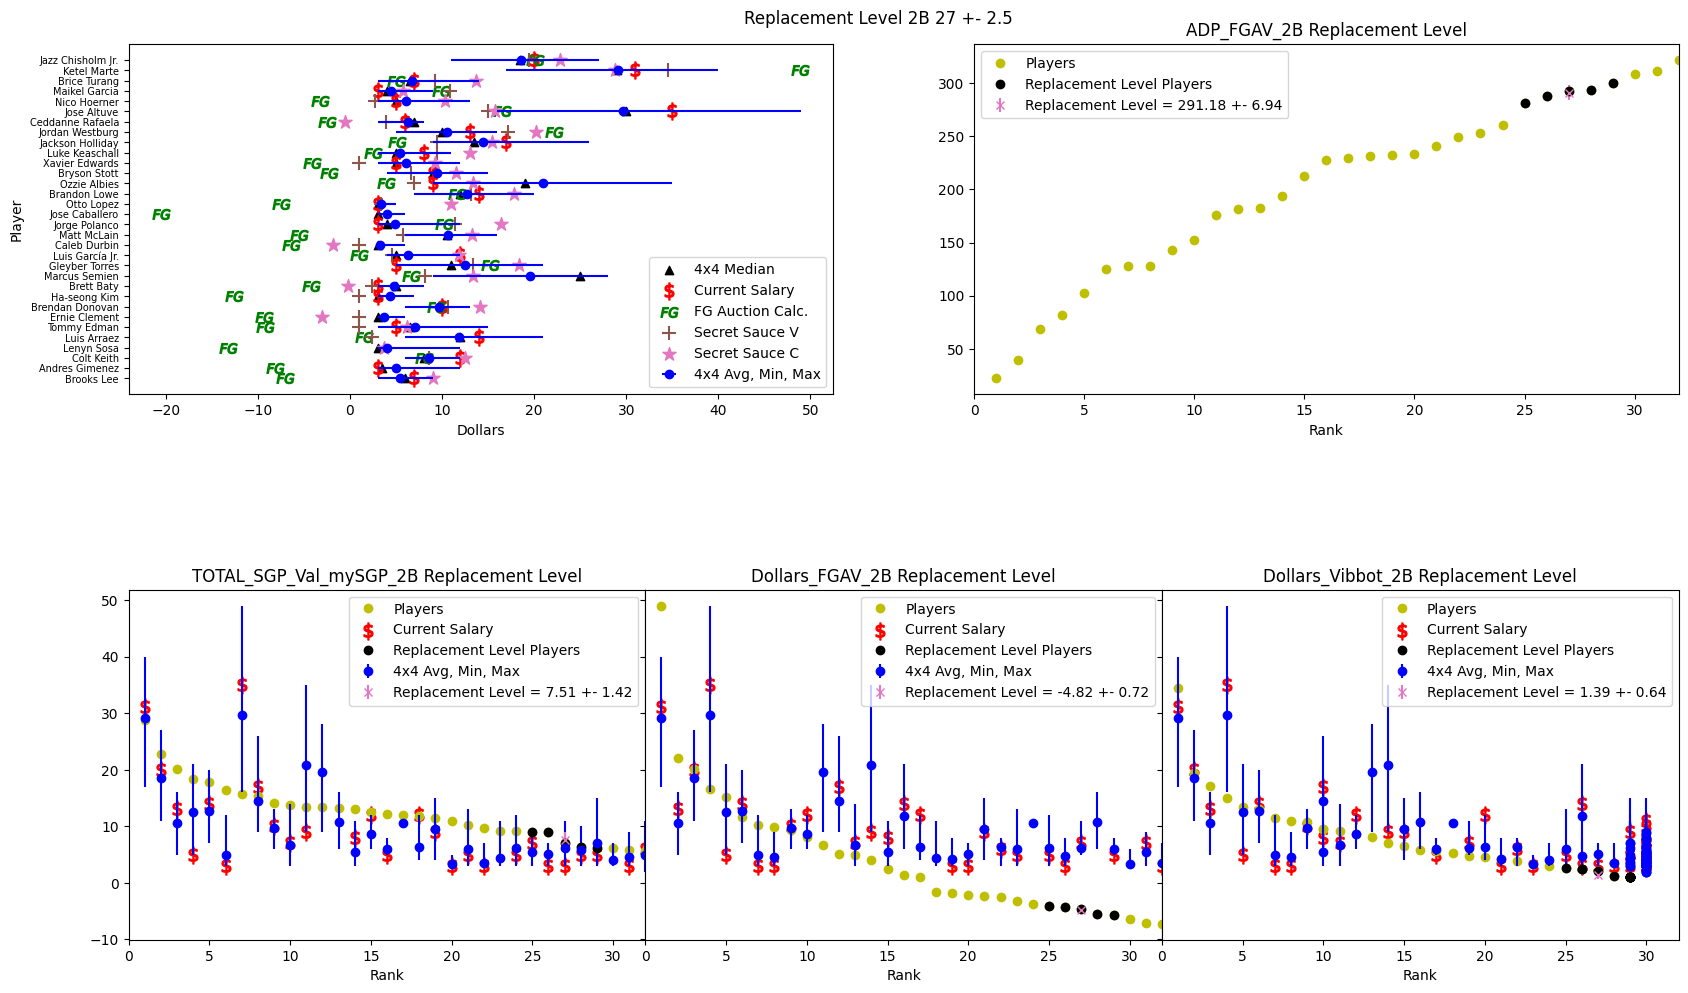

###################################
Position SS Replacement Level = 44
###################################
Replacement Level ADP_FGAV SS 420.20 +- 17.65


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_SS_rank
931,Jared Triolo,PIT,NaN,NaN,1B/2B/SS/3B,36984,404.53,-2.99,-13.46,1.0,3.00,3.0,3.0,3.0,NaN,42.0
339,Jake Cronenworth,SDP,197.0,St. CGT VI,1B/2B/SS,22004,405.86,12.21,-5.64,5.6,6.00,6.0,5.0,8.0,5.0,43.0
788,Brayan Rocchio,CLE,NaN,NaN,2B/SS,33650,412.61,5.22,-13.93,NaN,3.00,3.0,3.0,3.0,NaN,44.0
1280,Brooks Baldwin,CHW,NaN,NaN,2B/SS/3B/OF,42219,435.14,-9.24,-12.56,NaN,NaN,NaN,NaN,NaN,NaN,45.0
1223,Carson Williams,TBR,154.0,The Rime of Jamie Moyer,SS,40266,442.86,7.19,-18.68,NaN,4.65,4.0,3.0,7.0,4.0,46.0


ADP_FGAV 420.1999938964844  +-  17.645624489984076
Replacement Level TOTAL_SGP_Val_mySGP SS 2.36 +- 0.61


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_SS_rank,TOTAL_SGP_Val_mySGP_SS_rank
2432,Colt Emerson,SEA,253.0,Roar from 34,SS,44248,999.00,1.41,-21.93,NaN,3.59,4.0,2.0,6.0,3.0,76.0,46.0
957,Vaughn Grissom,LAA,NaN,NaN,2B/SS,37320,535.25,2.28,-20.92,NaN,NaN,NaN,NaN,NaN,NaN,56.0,45.0
1122,Thomas Saggese,STL,NaN,NaN,2B/SS/3B,38402,533.42,2.48,-19.13,NaN,4.00,4.0,4.0,4.0,NaN,55.0,44.0
1288,Ryan Ritter,COL,NaN,NaN,2B/SS,42405,626.42,2.55,-18.48,NaN,NaN,NaN,NaN,NaN,NaN,61.0,43.0
1312,Cole Young,SEA,240.0,Largely Indistinguishables,2B/SS,42582,523.58,3.10,-17.65,NaN,4.20,4.0,3.0,7.0,4.0,52.0,42.0


TOTAL_SGP_Val_mySGP 2.3631571131058537  +-  0.6117341719368689
Replacement Level Dollars_FGAV SS -14.21 +- 1.37


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_SS_rank,TOTAL_SGP_Val_mySGP_SS_rank,Dollars_FGAV_SS_rank
1188,Max Muncy,ATH,NaN,NaN,2B/SS/3B,40460,495.72,3.45,-16.53,NaN,5.00,5.0,3.0,7.0,NaN,51.0,41.0,46.0
2424,Kevin McGonigle,DET,241.0,🦫 Beavers in Scoring Position!,SS,44223,999.00,4.59,-14.09,1.0,4.42,4.0,2.0,8.0,2.0,76.0,40.0,45.0
788,Brayan Rocchio,CLE,NaN,NaN,2B/SS,33650,412.61,5.22,-13.93,NaN,3.00,3.0,3.0,3.0,NaN,44.0,38.0,44.0
931,Jared Triolo,PIT,NaN,NaN,1B/2B/SS/3B,36984,404.53,-2.99,-13.46,1.0,3.00,3.0,3.0,3.0,NaN,42.0,63.0,43.0
2883,Konnor Griffin,PIT,241.0,🦫 Beavers in Scoring Position!,SS,45769,999.00,7.69,-13.02,1.0,4.50,4.5,2.0,12.0,7.0,76.0,33.0,42.0


Dollars_FGAV -14.207236251639255  +-  1.3655273095945455
Dollars_Vibbot nan  +-  nan


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_13070/1875085877.py:110: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


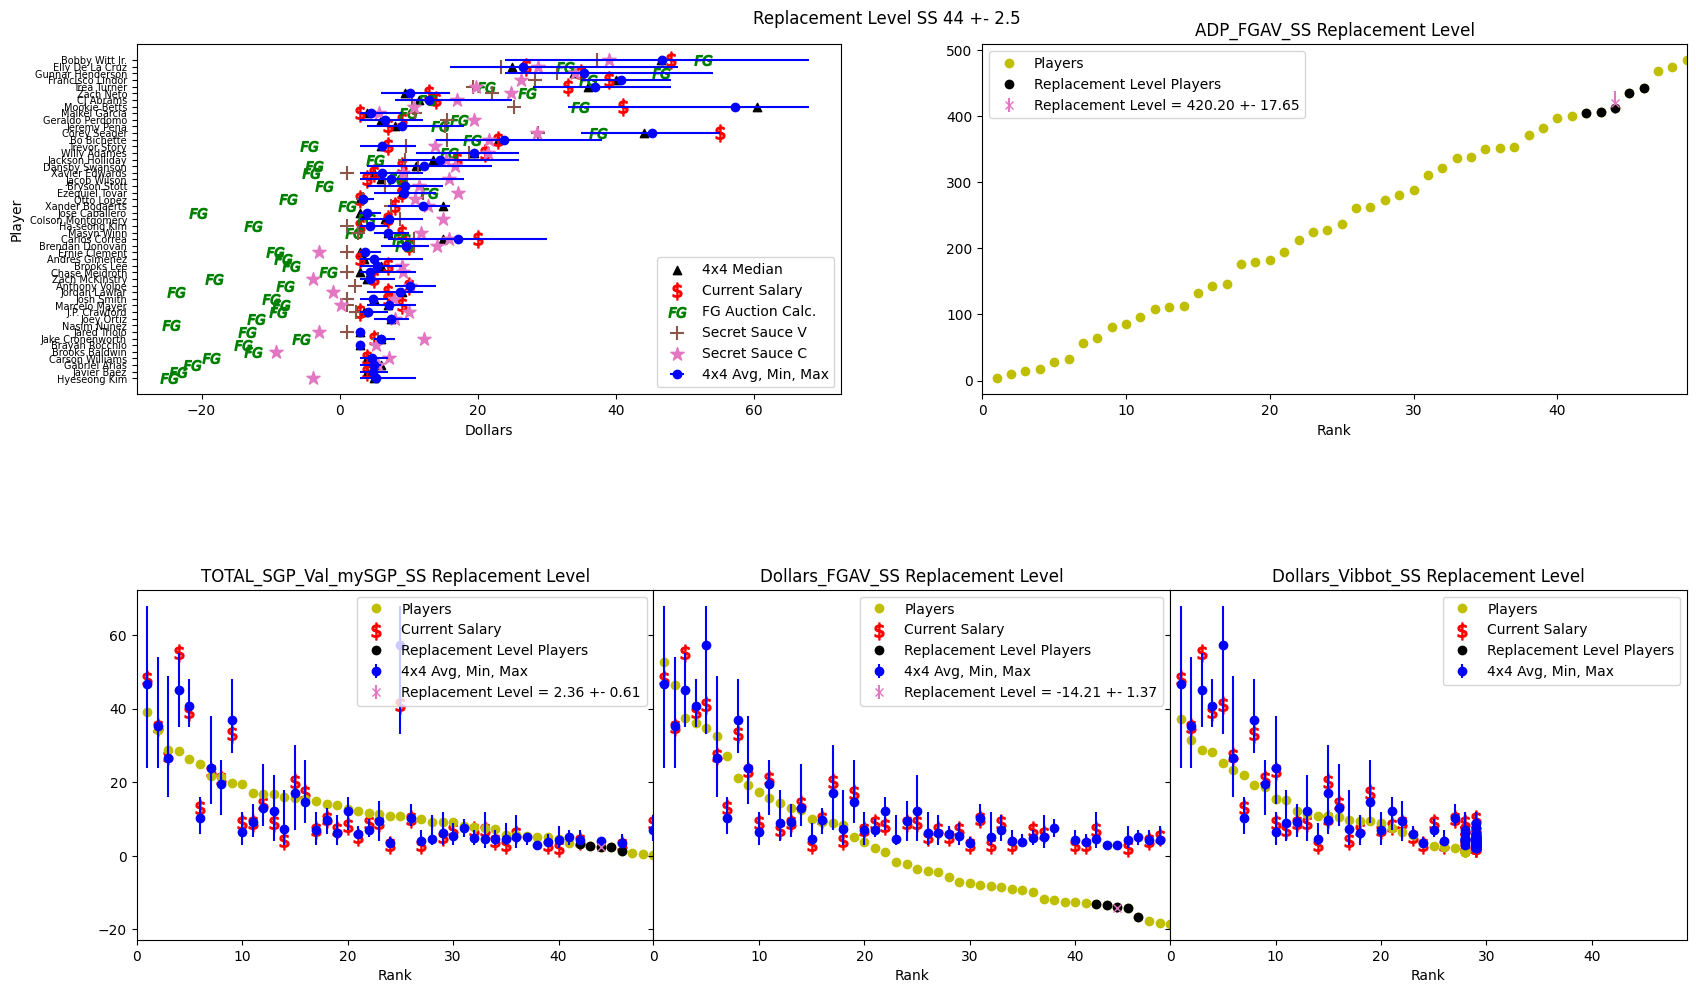

###################################
Position 3B Replacement Level = 19
###################################
Replacement Level ADP_FGAV 3B 235.66 +- 10.34


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_3B_rank
776,Jose Caballero,NaN,NaN,NaN,2B/SS/3B/OF,26915,227.44,NaN,-20.55,NaN,4.00,3.0,3.0,6.0,NaN,17.0
85,Jorge Polanco,NYM,185.0,Chili Dog MVP,2B/3B,13217,229.47,16.36,10.25,11.4,4.87,4.0,3.0,12.0,3.0,18.0
1178,Caleb Durbin,MIL,NaN,NaN,2B/3B,40398,232.00,-1.86,-6.44,1.0,3.30,3.0,3.0,6.0,NaN,19.0
1183,Colson Montgomery,CHW,247.0,Roberto Big Piece and the 69ers,SS/3B,40262,236.17,14.96,3.77,8.8,7.13,6.5,3.0,12.0,7.0,20.0
964,Brett Baty,NYM,253.0,Roar from 34,2B/3B,37181,253.22,-0.25,-4.26,2.4,4.75,5.0,3.0,8.0,3.0,21.0


ADP_FGAV 235.66000061035157  +-  10.34279683831222
Replacement Level TOTAL_SGP_Val_mySGP 3B 7.63 +- 1.36


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_3B_rank,TOTAL_SGP_Val_mySGP_3B_rank
447,Tommy Edman,LAD,90.0,Carlos Pérez's K-Dance,2B/3B/OF,31703,293.06,6.17,-9.22,1.0,7.08,6.5,3.0,15.0,5.0,28.0,21.0
521,Gavin Lux,TBR,154.0,The Rime of Jamie Moyer,2B/3B/OF,32576,521.78,6.27,-13.96,NaN,5.75,5.5,3.0,10.0,5.0,53.0,20.0
1003,Josh Smith,TEX,112.0,Hornswogglers,1B/SS/3B/OF,37960,353.39,7.82,-9.92,1.0,4.87,5.0,3.0,7.0,7.0,34.0,19.0
304,Alex Bregman,CHC,247.0,Roberto Big Piece and the 69ers,3B,18480,123.11,8.92,23.36,19.2,26.70,26.0,18.0,34.0,26.0,7.0,18.0
715,Nolan Gorman,STL,253.0,Roar from 34,2B/3B,33623,437.31,8.96,-2.09,2.1,5.14,6.0,3.0,7.0,3.0,43.0,17.0


TOTAL_SGP_Val_mySGP 7.627592394949903  +-  1.3638849855714186
Replacement Level Dollars_FGAV 3B 3.53 +- 0.99


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_3B_rank,TOTAL_SGP_Val_mySGP_3B_rank,Dollars_FGAV_3B_rank
1019,Noelvi Marte,CIN,55.0,Jack Klugman's Second Best Lung,3B/OF,36030,142.14,3.51,2.64,6.1,7.21,7.0,3.0,17.0,14.0,10.0,29.0,21.0
579,Royce Lewis,MIN,241.0,🦫 Beavers in Scoring Position!,3B,23796,199.14,4.10,2.85,7.2,13.53,14.0,7.0,19.0,15.0,12.0,25.0,20.0
701,Mark Vientos,NYM,55.0,Jack Klugman's Second Best Lung,3B,26857,278.28,4.16,3.27,5.5,8.05,8.0,4.0,13.0,13.0,25.0,24.0,19.0
1183,Colson Montgomery,CHW,247.0,Roberto Big Piece and the 69ers,SS/3B,40262,236.17,14.96,3.77,8.8,7.13,6.5,3.0,12.0,7.0,20.0,10.0,18.0
1289,Sal Stewart,CIN,185.0,Chili Dog MVP,1B/3B,42358,214.69,14.91,5.12,11.7,5.38,4.5,3.0,13.0,13.0,15.0,11.0,17.0


Dollars_FGAV 3.5314599836872644  +-  0.9895900892941228
Replacement Level Dollars_Vibbot 3B 8.50 +- 1.05


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_3B_rank,TOTAL_SGP_Val_mySGP_3B_rank,Dollars_FGAV_3B_rank,Dollars_Vibbot_3B_rank
579,Royce Lewis,MIN,241.0,🦫 Beavers in Scoring Position!,3B,23796,199.14,4.10,2.85,7.2,13.53,14.0,7.0,19.0,15.0,12.0,25.0,20.0,21.0
656,Alec Bohm,PHI,240.0,Largely Indistinguishables,1B/3B,33609,273.61,3.76,-0.58,7.9,10.73,11.0,3.0,15.0,15.0,24.0,28.0,23.0,20.0
1124,Colt Keith,DET,90.0,Carlos Pérez's K-Dance,1B/2B/3B,38374,308.17,12.46,8.05,8.6,8.63,8.0,6.0,12.0,12.0,29.0,13.0,15.0,19.0
1183,Colson Montgomery,CHW,247.0,Roberto Big Piece and the 69ers,SS/3B,40262,236.17,14.96,3.77,8.8,7.13,6.5,3.0,12.0,7.0,20.0,10.0,18.0,18.0
552,Miguel Vargas,CHW,197.0,St. CGT VI,1B/3B,34804,278.69,4.72,-3.97,10.0,4.11,3.0,3.0,9.0,8.0,26.0,23.0,26.0,17.0


Dollars_Vibbot 8.5  +-  1.0488088481701514


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_13070/1875085877.py:110: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


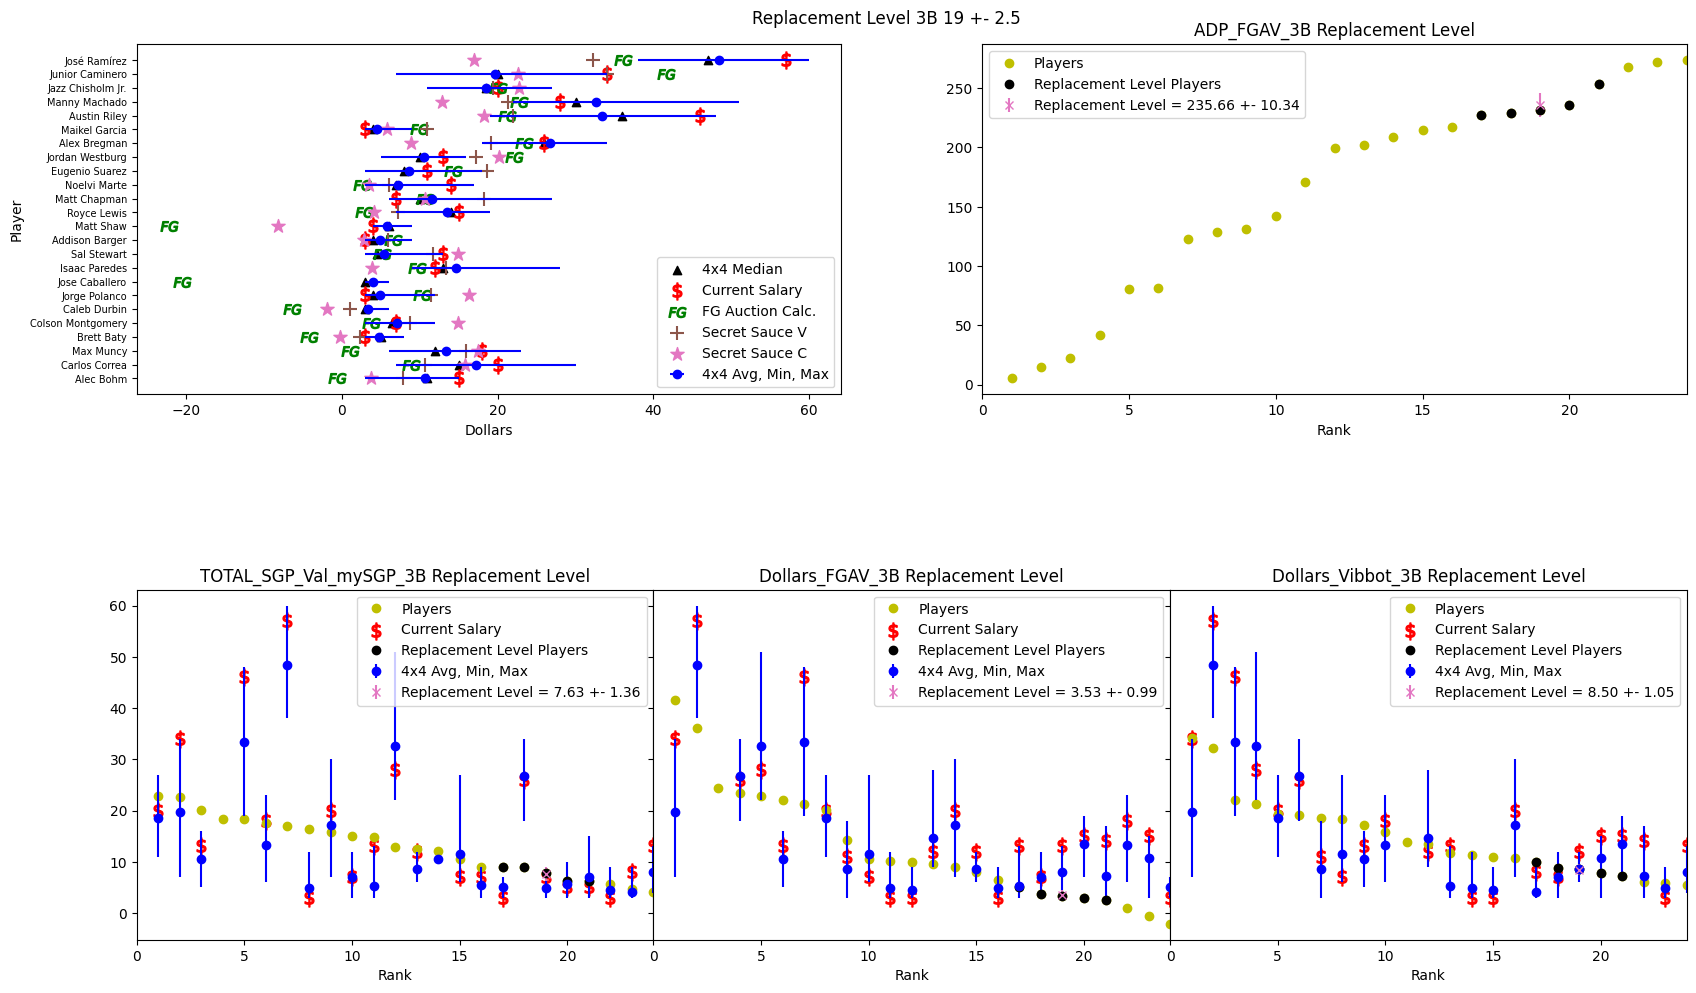

###################################
Position MI Replacement Level = 63
###################################
Replacement Level ADP_FGAV MI 383.03 +- 10.60


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_MI_rank
1179,Marcelo Mayer,BOS,90.0,Carlos Pérez's K-Dance,2B/SS/3B,40095,371.67,0.19,-8.45,1.0,7.09,7.0,4.0,11.0,9.0,61.0
1179,Marcelo Mayer,BOS,90.0,Carlos Pérez's K-Dance,2B/SS/3B,40095,371.67,0.19,-8.45,1.0,7.09,7.0,4.0,11.0,9.0,61.0
641,Jonathan India,KCR,NaN,NaN,2B/3B/OF,33619,381.78,12.05,-3.81,5.2,10.50,10.5,10.0,11.0,NaN,62.0
184,J.P. Crawford,SEA,236.0,Yoshi Teddy Bear,SS,18272,382.58,10.03,-8.89,2.4,4.13,3.5,3.0,7.0,3.0,63.0
595,Kody Clemens,MIN,236.0,Yoshi Teddy Bear,1B/2B/OF,35487,393.89,2.93,-16.19,NaN,3.40,3.0,3.0,7.0,3.0,64.0
901,Joey Ortiz,MIL,NaN,NaN,SS,36743,396.61,8.06,-12.05,NaN,7.50,7.5,5.0,10.0,NaN,65.0


ADP_FGAV 383.03333536783856  +-  10.603956417732663
Replacement Level TOTAL_SGP_Val_mySGP MI 4.16 +- 0.69


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_MI_rank,TOTAL_SGP_Val_mySGP_MI_rank
1188,Max Muncy,ATH,NaN,NaN,2B/SS/3B,40460,495.72,3.45,-16.53,NaN,5.00,5.0,3.0,7.0,NaN,83.0,65.0
1188,Max Muncy,ATH,NaN,NaN,2B/SS/3B,40460,495.72,3.45,-16.53,NaN,5.00,5.0,3.0,7.0,NaN,83.0,65.0
756,Lenyn Sosa,CHW,NaN,NaN,1B/2B,26411,300.11,3.73,-13.25,NaN,4.08,3.0,3.0,12.0,NaN,50.0,64.0
1070,Casey Schmitt,SFG,NaN,NaN,1B/2B/3B,38383,480.94,3.88,-16.60,1.0,3.00,3.0,3.0,3.0,NaN,80.0,63.0
2424,Kevin McGonigle,DET,241.0,🦫 Beavers in Scoring Position!,SS,44223,999.00,4.59,-14.09,1.0,4.42,4.0,2.0,8.0,2.0,136.0,62.0
1049,Nick Gonzales,PIT,241.0,🦫 Beavers in Scoring Position!,2B/SS,38314,523.72,5.00,-12.70,NaN,3.71,3.0,3.0,6.0,3.0,88.0,61.0
1049,Nick Gonzales,PIT,241.0,🦫 Beavers in Scoring Position!,2B/SS,38314,523.72,5.00,-12.70,NaN,3.71,3.0,3.0,6.0,3.0,88.0,61.0


TOTAL_SGP_Val_mySGP 4.15587790845675  +-  0.6895543451645383
Replacement Level Dollars_FGAV MI -11.54 +- 1.06


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_MI_rank,TOTAL_SGP_Val_mySGP_MI_rank,Dollars_FGAV_MI_rank
1280,Brooks Baldwin,CHW,NaN,NaN,2B/SS/3B/OF,42219,435.14,-9.24,-12.56,NaN,NaN,NaN,NaN,NaN,NaN,73.0,155.0,65.0
1280,Brooks Baldwin,CHW,NaN,NaN,2B/SS/3B/OF,42219,435.14,-9.24,-12.56,NaN,NaN,NaN,NaN,NaN,NaN,73.0,155.0,65.0
901,Joey Ortiz,MIL,NaN,NaN,SS,36743,396.61,8.06,-12.05,NaN,7.50,7.5,5.0,10.0,NaN,65.0,49.0,64.0
2613,JJ Wetherholt,STL,240.0,Largely Indistinguishables,2B/SS,45713,999.00,5.69,-11.72,NaN,5.00,4.5,2.0,11.0,6.0,136.0,58.0,63.0
2613,JJ Wetherholt,STL,240.0,Largely Indistinguishables,2B/SS,45713,999.00,5.69,-11.72,NaN,5.00,4.5,2.0,11.0,6.0,136.0,58.0,63.0
734,Tyler Freeman,COL,NaN,NaN,2B/OF,26882,428.31,-7.62,-10.24,1.0,4.86,5.0,3.0,7.0,NaN,72.0,153.0,62.0
1003,Josh Smith,TEX,112.0,Hornswogglers,1B/SS/3B/OF,37960,353.39,7.82,-9.92,1.0,4.87,5.0,3.0,7.0,7.0,59.0,50.0,61.0


Dollars_FGAV -11.53878520778076  +-  1.058594788029991
Dollars_Vibbot nan  +-  nan


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_13070/1875085877.py:110: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


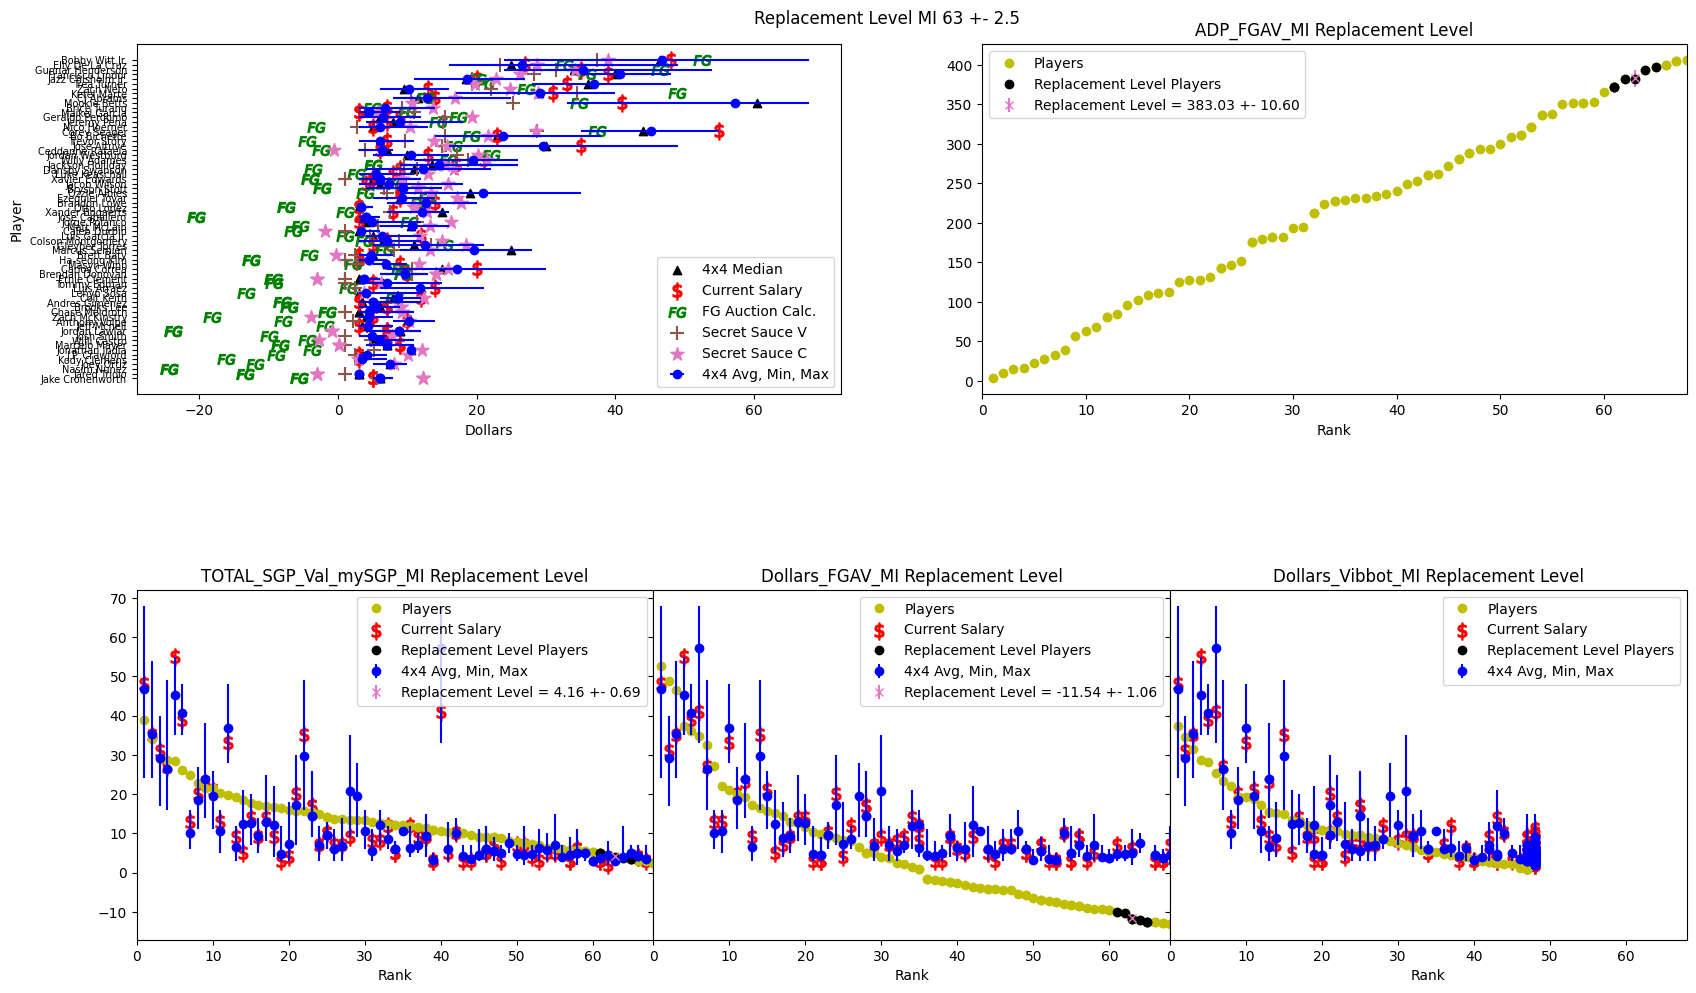

###################################
Position OF Replacement Level = 89
###################################
Replacement Level ADP_FGAV OF 351.45 +- 4.83


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_OF_rank
971,Jake Mangum,PIT,NaN,NaN,OF,37660,345.72,-13.61,-21.60,NaN,3.00,3.0,3.0,3.0,NaN,87.0
555,Brandon Marsh,PHI,240.0,Largely Indistinguishables,OF,23868,348.06,-0.70,-4.37,6.2,5.00,5.0,3.0,8.0,3.0,88.0
176,Jeff Mcneil,NaN,197.0,St. CGT VI,2B/OF,18644,351.89,NaN,-1.84,4.2,4.25,3.5,3.0,8.0,3.0,89.0
1003,Josh Smith,TEX,112.0,Hornswogglers,1B/SS/3B/OF,37960,353.39,7.82,-9.92,1.0,4.87,5.0,3.0,7.0,7.0,90.0
1389,Cam Smith,HOU,242.0,Smoak and Mirrors,OF,45714,358.17,-6.59,-12.17,NaN,6.54,5.0,3.0,17.0,9.0,91.0


ADP_FGAV 351.4460083007813  +-  4.833238383607121
Replacement Level TOTAL_SGP_Val_mySGP OF -2.42 +- 0.16


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_OF_rank,TOTAL_SGP_Val_mySGP_OF_rank
1057,Nick Yorke,PIT,NaN,NaN,2B/OF,38436,690.53,-2.60,-24.38,NaN,3.00,3.0,3.0,3.0,NaN,164.0,91.0
2033,Jett Williams,MIL,240.0,Largely Indistinguishables,2B/SS/OF,42175,999.00,-2.58,-25.42,NaN,4.53,4.0,2.0,10.0,10.0,209.0,90.0
877,Daniel Schneemann,CLE,197.0,St. CGT VI,2B/SS/3B/OF,34843,608.72,-2.33,-23.85,NaN,6.00,5.5,4.0,10.0,5.0,147.0,89.0
1278,Jakob Marsee,MIA,240.0,Largely Indistinguishables,OF,42169,150.81,-2.29,-1.01,6.2,5.96,5.5,3.0,14.0,14.0,37.0,88.0
346,LaMonte Wade Jr.,CHW,NaN,NaN,1B/OF,21964,999.00,-2.27,-22.91,NaN,NaN,NaN,NaN,NaN,NaN,209.0,87.0


TOTAL_SGP_Val_mySGP -2.415617003957833  +-  0.16060645029605966
Replacement Level Dollars_FGAV OF -7.52 +- 0.36


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_OF_rank,TOTAL_SGP_Val_mySGP_OF_rank,Dollars_FGAV_OF_rank
520,Josh Lowe,LAA,NaN,NaN,OF,23752,272.64,-4.51,-7.99,1.0,7.50,7.5,5.0,10.0,NaN,70.0,118.0,91.0
1314,Dylan Beavers,BAL,241.0,🦫 Beavers in Scoring Position!,OF,42279,309.94,-4.23,-7.58,2.3,5.27,4.0,3.0,14.0,14.0,76.0,112.0,90.0
686,Christopher Morel,MIA,NaN,NaN,OF,26080,532.86,-2.87,-7.53,NaN,10.75,11.0,7.0,14.0,NaN,131.0,94.0,89.0
1172,Sal Frelick,MIL,240.0,Largely Indistinguishables,OF,40298,206.72,-5.34,-7.48,1.1,4.39,3.0,3.0,9.0,7.0,52.0,127.0,88.0
735,George Valera,CLE,NaN,NaN,OF,33605,628.08,-3.67,-6.99,NaN,3.50,3.5,3.0,4.0,NaN,152.0,103.0,87.0


Dollars_FGAV -7.5162948736663635  +-  0.3569740835635352
Dollars_Vibbot nan  +-  nan


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_13070/1875085877.py:110: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


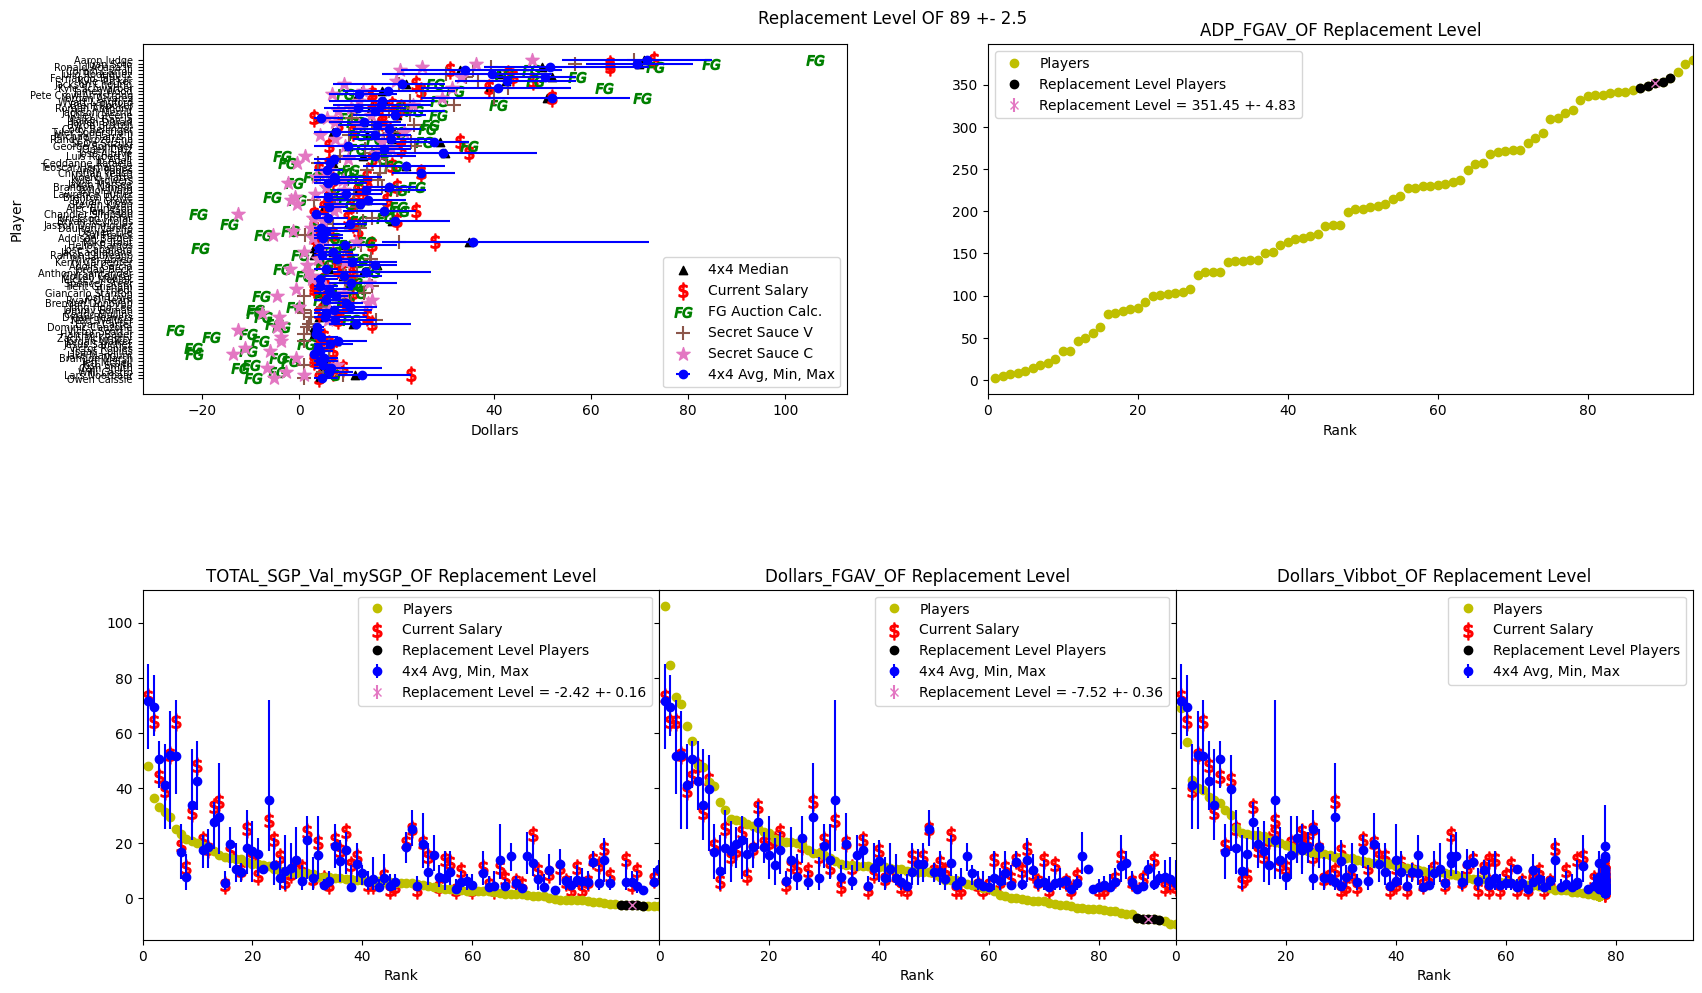

###################################
Position Util Replacement Level = 233
###################################
Replacement Level ADP_FGAV Util 410.43 +- 3.58


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_Util_rank
652,Romy Gonzalez,BOS,247.0,Roberto Big Piece and the 69ers,1B/2B,34602,406.28,9.62,-7.23e+00,1.3,3.53,3.0,3.0,7.0,3.0,231.0
200,Tyler O'Neill,BAL,242.0,Smoak and Mirrors,OF,19296,406.89,-1.25,-3.26e-03,7.1,13.11,13.0,11.0,17.0,14.0,232.0
261,Lane Thomas,KCR,NaN,NaN,OF,21041,412.31,-6.63,-1.01e+01,1.0,6.50,6.5,6.0,7.0,NaN,233.0
788,Brayan Rocchio,CLE,NaN,NaN,2B/SS,33650,412.61,5.22,-1.39e+01,NaN,3.00,3.0,3.0,3.0,NaN,234.0
167,Ryan McMahon,NYY,197.0,St. CGT VI,3B,18328,414.08,-1.24,-1.67e+01,3.5,7.57,8.5,3.0,16.0,3.0,235.0


ADP_FGAV 410.4339965820312  +-  3.5834011598214808
Replacement Level TOTAL_SGP_Val_mySGP Util -1.61 +- 0.08


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_Util_rank,TOTAL_SGP_Val_mySGP_Util_rank
1364,Dylan Crews,WSN,185.0,Chili Dog MVP,OF,43950,168.11,-1.69,-0.52,3.1,14.05,14.0,6.0,22.0,18.0,94.0,235.0
792,Ronny Mauricio,NYM,NaN,NaN,2B/3B,33640,517.69,-1.69,-19.47,NaN,6.67,5.5,4.0,12.0,NaN,282.0,234.0
244,Danny Jansen,TEX,NaN,NaN,C,19481,446.00,-1.62,0.94,NaN,11.00,11.0,11.0,11.0,NaN,252.0,233.0
606,Leo Rivas,SEA,NaN,NaN,2B/SS,22233,999.00,-1.55,-24.46,NaN,NaN,NaN,NaN,NaN,NaN,449.0,232.0
1061,David Hamilton,BOS,NaN,NaN,2B/SS,38344,723.42,-1.51,-23.17,NaN,NaN,NaN,NaN,NaN,NaN,383.0,231.0


TOTAL_SGP_Val_mySGP -1.6123272655899872  +-  0.08209879869004268
Replacement Level Dollars_FGAV Util -9.83 +- 0.13


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_Util_rank,TOTAL_SGP_Val_mySGP_Util_rank,Dollars_FGAV_Util_rank
209,Luis Torrens,NYM,NaN,NaN,C,19981,667.53,-6.89,-9.93,NaN,NaN,NaN,NaN,NaN,NaN,348.0,374.0,235.0
1003,Josh Smith,TEX,112.0,Hornswogglers,1B/SS/3B/OF,37960,353.39,7.82,-9.92,1.0,4.87,5.0,3.0,7.0,7.0,205.0,121.0,234.0
647,Nick Fortes,TBR,NaN,NaN,C,34653,613.33,-7.56,-9.88,NaN,NaN,NaN,NaN,NaN,NaN,326.0,384.0,233.0
253,Jose Trevino,CIN,NaN,NaN,C,20399,702.08,-7.67,-9.79,NaN,NaN,NaN,NaN,NaN,NaN,362.0,387.0,232.0
1052,Owen Caissie,MIA,55.0,Jack Klugman's Second Best Lung,OF,38367,379.06,-5.14,-9.62,1.0,4.60,4.0,3.0,8.0,4.0,213.0,339.0,231.0


Dollars_FGAV -9.82714045278293  +-  0.13034249283165208
Dollars_Vibbot nan  +-  nan


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_13070/1875085877.py:110: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


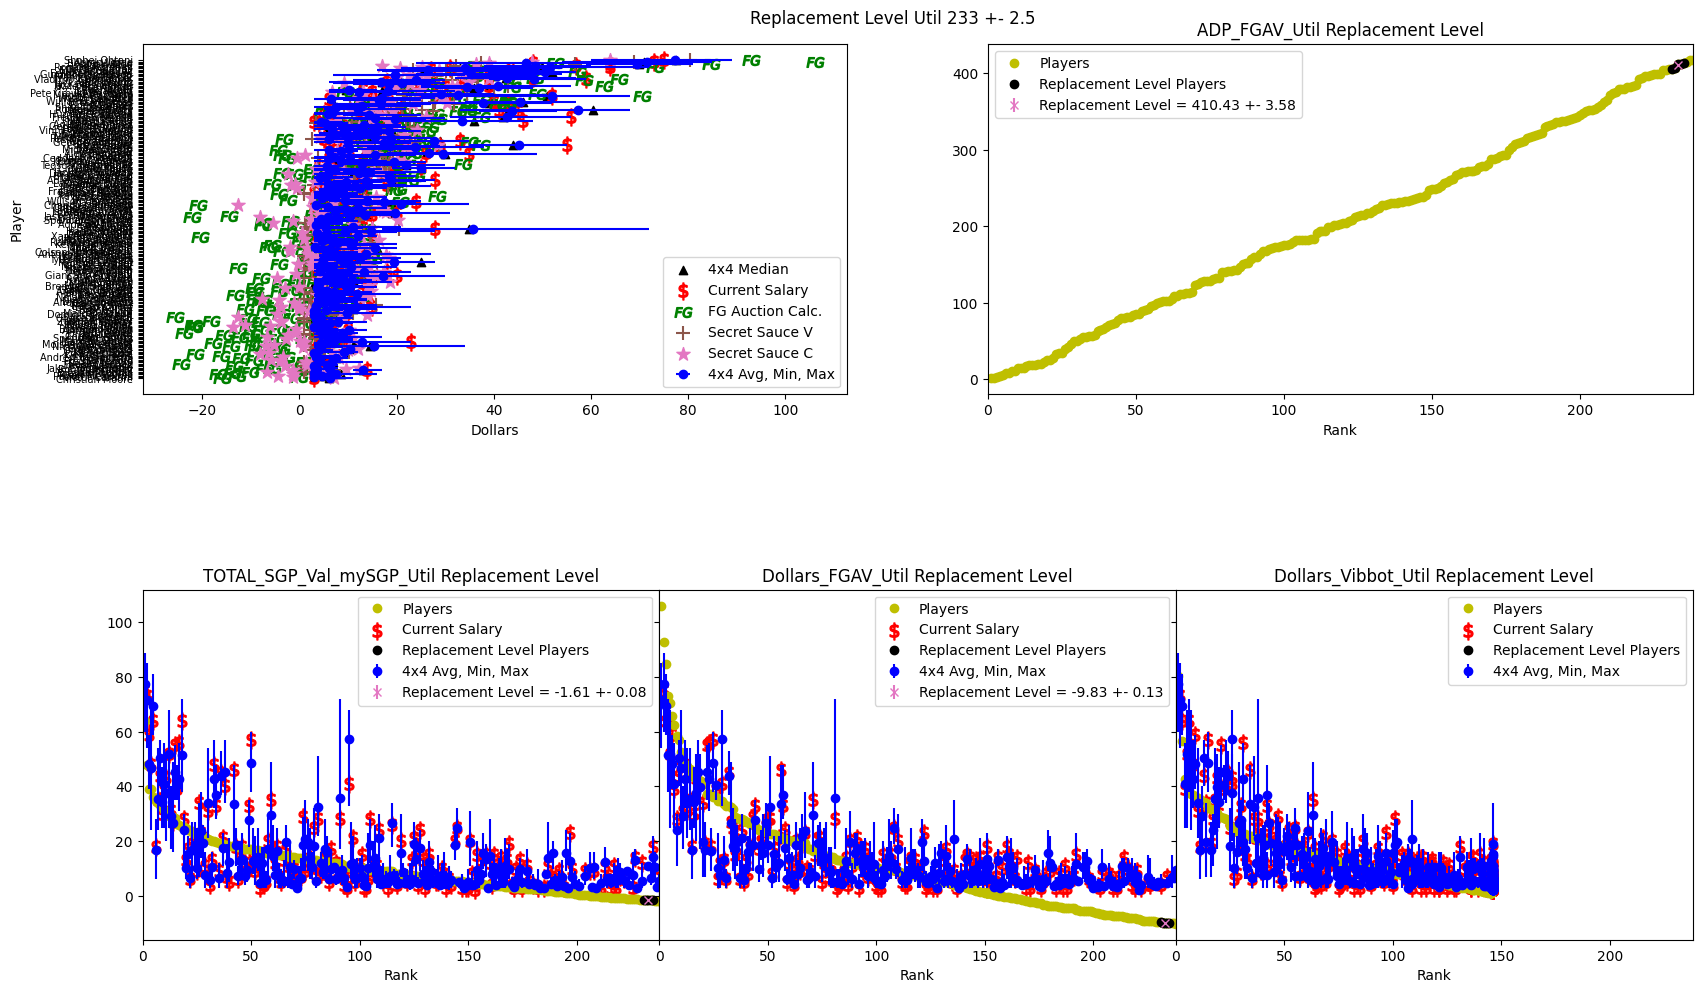

###################################
Position SP Replacement Level = 150
###################################
Replacement Level ADP_FGAV SP 548.52 +- 7.40


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_SP_rank
86,Eduardo Rodriguez,ARI,NaN,NaN,SP,13335,540.00,0.91,-27.31,NaN,7.00,7.0,7.0,7.0,NaN,148.0
1068,Carmen Mlodzinski,PIT,NaN,NaN,SP/RP,38403,541.14,3.17,-1.61,1.5,3.00,3.0,3.0,3.0,NaN,149.0
430,Corbin Burnes,ARI,NaN,NaN,SP,23813,551.50,0.08,13.42,3.2,14.18,13.0,7.0,24.0,NaN,150.0
1192,Robert Gasser,MIL,247.0,Roberto Big Piece and the 69ers,SP/RP,40476,554.72,3.82,-5.01,NaN,3.75,3.5,3.0,5.0,5.0,151.0
1277,Max Scherzer,NaN,236.0,Yoshi Teddy Bear,SP,4514,555.22,NaN,-16.59,NaN,5.00,4.5,3.0,8.0,5.0,152.0


ADP_FGAV 548.5159912109375  +-  7.4037853085376195
Replacement Level TOTAL_SGP_Val_mySGP SP -1.00 +- 0.18


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_SP_rank,TOTAL_SGP_Val_mySGP_SP_rank
1264,Didier Fuentes,ATL,NaN,NaN,SP/RP,41452,NaN,-1.10,NaN,NaN,4.5,4.5,4.0,5.0,NaN,221.0,152.0
2463,Tate Kuehner,MIL,NaN,NaN,SP,44375,NaN,-1.10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,221.0,151.0
1566,Coleman Crow,MIL,NaN,NaN,SP,38793,999.0,-1.08,2.59,NaN,NaN,NaN,NaN,NaN,NaN,220.0,150.0
2466,Andrew Sears,DET,NaN,NaN,SP,44398,NaN,-1.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,221.0,149.0
634,Stephen Kolek,KCR,NaN,NaN,SP,35475,617.5,-0.68,-4.38,NaN,6.0,6.0,3.0,9.0,NaN,165.0,148.0


TOTAL_SGP_Val_mySGP -0.9957030101429508  +-  0.17949605527632223
Replacement Level Dollars_FGAV SP -11.69 +- 0.25


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_SP_rank,TOTAL_SGP_Val_mySGP_SP_rank,Dollars_FGAV_SP_rank
1248,Carlos Rodriguez,MIL,NaN,NaN,SP/RP,40951,999.00,-13.67,-12.01,NaN,NaN,NaN,NaN,NaN,NaN,220.0,331.0,152.0
158,Jon Gray,NaN,NaN,NaN,SP/RP,18244,999.00,NaN,-11.77,NaN,3.00,3.0,3.0,3.0,NaN,220.0,370.0,151.0
737,Taj Bradley,MIN,236.0,Yoshi Teddy Bear,SP,35367,410.53,5.13,-11.75,NaN,8.25,8.0,4.0,15.0,8.0,118.0,94.0,150.0
1319,AJ Blubaugh,HOU,NaN,NaN,SP/RP,42340,568.00,-19.52,-11.56,NaN,3.33,3.0,3.0,4.0,NaN,156.0,354.0,149.0
1041,Max Meyer,MIA,154.0,The Rime of Jamie Moyer,SP,38307,408.25,6.35,-11.34,NaN,4.07,4.0,3.0,8.0,4.0,117.0,82.0,148.0


Dollars_FGAV -11.685913411248967  +-  0.2479646944703743
Dollars_Vibbot nan  +-  nan


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_13070/1875085877.py:110: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


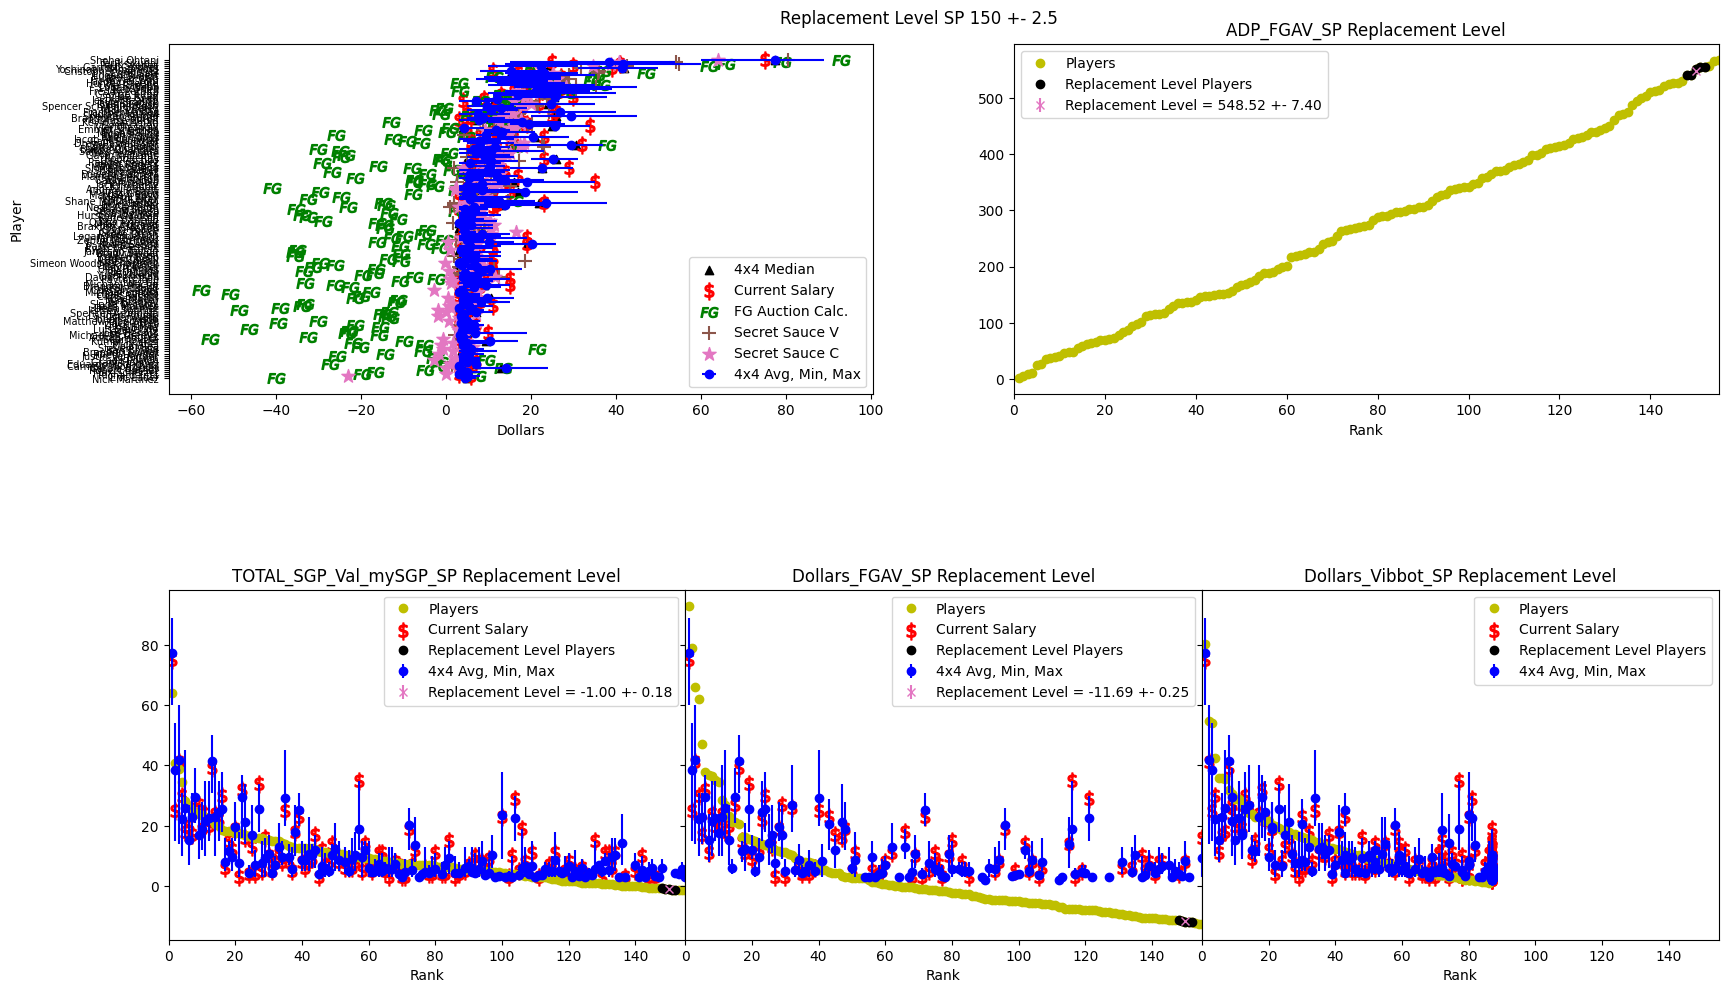

###################################
Position RP Replacement Level = 65
###################################
Replacement Level ADP_FGAV RP 449.59 +- 5.82


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_RP_rank
296,Tanner Scott,LAD,NaN,NaN,RP,21075,443.64,6.44,4.12,3.1,7.67,7.0,7.0,9.0,NaN,63.0
258,Luke Weaver,NYM,NaN,NaN,RP,18380,446.44,-7.26,1.08,NaN,4.93,5.0,3.0,7.0,NaN,64.0
458,JoJo Romero,STL,NaN,NaN,RP,23818,448.33,4.56,-2.36,1.9,3.67,3.0,3.0,6.0,NaN,65.0
343,Phil Maton,CHC,247.0,Roberto Big Piece and the 69ers,RP,22809,450.61,6.23,-3.09,2.9,3.53,3.0,3.0,6.0,3.0,66.0
515,Tony Santillan,CIN,154.0,The Rime of Jamie Moyer,RP,22679,458.94,-16.92,-16.95,NaN,3.00,3.0,3.0,3.0,3.0,67.0


ADP_FGAV 449.5919982910156  +-  5.81754544346015
Replacement Level TOTAL_SGP_Val_mySGP RP 4.93 +- 0.45


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_RP_rank,TOTAL_SGP_Val_mySGP_RP_rank
458,JoJo Romero,STL,NaN,NaN,RP,23818,448.33,4.56,-2.36,1.9,3.67,3.0,3.0,6.0,NaN,65.0,67.0
472,Gregory Soto,PIT,NaN,NaN,RP,19136,590.64,4.62,1.18,1.9,3.00,3.0,3.0,3.0,NaN,112.0,66.0
1174,Matt Svanson,STL,NaN,NaN,RP,40308,463.58,4.63,-6.75,2.7,3.00,3.0,3.0,3.0,NaN,71.0,65.0
1120,Jared Jones,PIT,154.0,The Rime of Jamie Moyer,RP,38361,424.25,5.38,8.11,5.5,8.27,8.5,5.0,15.0,6.0,59.0,64.0
1060,Jared Koenig,MIL,NaN,NaN,RP,38641,750.33,5.45,3.44,2.8,3.00,3.0,3.0,3.0,NaN,212.0,63.0


TOTAL_SGP_Val_mySGP 4.928325805648086  +-  0.44563313513486985
Replacement Level Dollars_FGAV RP 2.79 +- 0.17


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_RP_rank,TOTAL_SGP_Val_mySGP_RP_rank,Dollars_FGAV_RP_rank
1370,Connelly Early,BOS,185.0,Chili Dog MVP,SP/RP,44515,222.33,2.26,2.64,6.7,8.58,8.0,3.0,18.0,11.0,27.0,88.0,67.0
623,Bennett Sousa,HOU,NaN,NaN,RP,35941,999.00,2.87,2.69,NaN,4.50,4.5,3.0,6.0,NaN,220.0,84.0,66.0
748,Angel Zerpa,MIL,NaN,NaN,RP,25903,728.69,7.10,2.69,NaN,NaN,NaN,NaN,NaN,NaN,162.0,49.0,65.0
224,Aaron Bummer,ATL,90.0,Carlos Pérez's K-Dance,RP,29222,999.00,9.22,2.88,3.5,3.00,3.0,3.0,3.0,3.0,220.0,38.0,64.0
335,Pete Fairbanks,MIA,55.0,Jack Klugman's Second Best Lung,RP,20435,90.22,9.68,3.04,3.0,5.84,5.0,3.0,10.0,4.0,13.0,34.0,63.0


Dollars_FGAV 2.78543451402372  +-  0.16674677158450188
Dollars_Vibbot nan  +-  nan


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_13070/1875085877.py:110: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


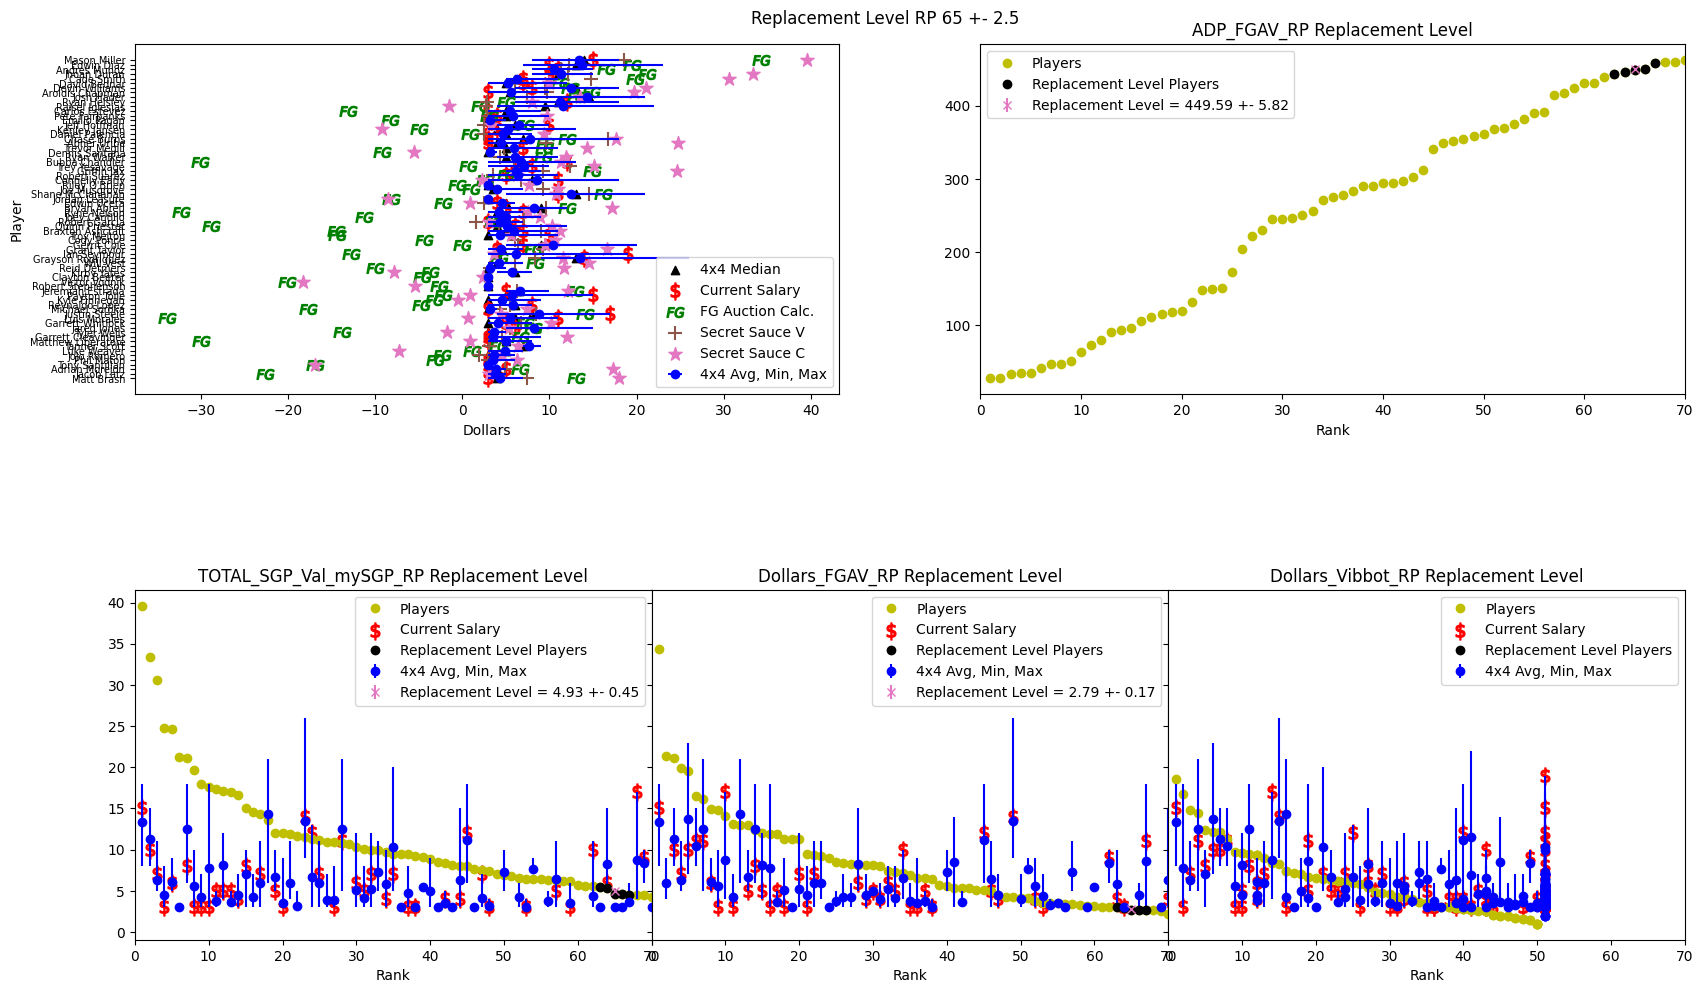

###################################
Position P Replacement Level = 215
###################################
Replacement Level ADP_FGAV P 544.72 +- 3.88


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_P_rank
86,Eduardo Rodriguez,ARI,NaN,NaN,SP,13335,540.00,0.91,-27.31,NaN,7.00,7.0,7.0,7.0,NaN,213.0
1068,Carmen Mlodzinski,PIT,NaN,NaN,SP/RP,38403,541.14,3.17,-1.61,1.5,3.00,3.0,3.0,3.0,NaN,214.0
852,Kyle Leahy,STL,NaN,NaN,RP,35030,546.36,4.14,-27.12,NaN,3.33,3.0,3.0,4.0,NaN,215.0
1094,Louis Varland,TOR,253.0,Roar from 34,RP,37202,547.56,6.47,6.40,NaN,3.09,3.0,3.0,4.0,3.0,216.0
190,Mark Leiter Jr.,ATH,NaN,NaN,RP,19574,548.53,-13.00,-5.95,NaN,4.33,3.0,3.0,7.0,NaN,217.0


ADP_FGAV 544.7180053710938  +-  3.8847823798085384
Replacement Level TOTAL_SGP_Val_mySGP P 0.45 +- 0.04


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_P_rank,TOTAL_SGP_Val_mySGP_P_rank
941,Bryan King,HOU,55.0,Jack Klugman's Second Best Lung,RP,37210,750.44,0.41,-0.95,2.1,3.55,3.0,3.0,5.0,3.0,362.0,217.0
2,Caleb Thielbar,CHC,NaN,NaN,RP,6225,749.22,0.42,0.01,NaN,3.00,3.0,3.0,3.0,NaN,344.0,216.0
1029,Edgardo Henriquez,LAD,NaN,NaN,RP,36539,NaN,0.45,NaN,NaN,3.14,3.0,3.0,4.0,NaN,371.0,215.0
617,Bailey Ober,MIN,90.0,Carlos Pérez's K-Dance,SP,32966,305.19,0.46,-16.08,NaN,10.25,10.5,5.0,16.0,11.0,119.0,214.0
479,Anthony Bender,MIA,NaN,NaN,RP,32871,746.03,0.50,-7.30,NaN,3.67,3.0,3.0,5.0,NaN,329.0,213.0


TOTAL_SGP_Val_mySGP 0.4488020554860201  +-  0.03523686005348111
Replacement Level Dollars_FGAV P -4.56 +- 0.04


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_P_rank,TOTAL_SGP_Val_mySGP_P_rank,Dollars_FGAV_P_rank
1220,Joe Rock,TBR,NaN,NaN,SP/RP,40747,750.72,-9.41,-4.61,NaN,NaN,NaN,NaN,NaN,NaN,367.0,575.0,217.0
631,Cole Sands,MIN,NaN,NaN,RP,35878,509.42,-3.55,-4.59,NaN,3.00,3.0,3.0,3.0,NaN,197.0,334.0,216.0
1380,Andrew Walters,CLE,NaN,NaN,RP,44588,999.00,-4.26,-4.56,NaN,NaN,NaN,NaN,NaN,NaN,370.0,365.0,215.0
101,Steven Okert,HOU,242.0,Smoak and Mirrors,RP,18421,749.83,-6.01,-4.54,NaN,3.57,3.0,3.0,9.0,4.0,356.0,474.0,214.0
291,Jack Flaherty,DET,185.0,Chili Dog MVP,SP,20920,217.64,12.59,-4.52,11.8,8.56,8.0,5.0,15.0,8.0,84.0,55.0,213.0


Dollars_FGAV -4.562731738773397  +-  0.036659998275013594
Dollars_Vibbot nan  +-  nan


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_13070/1875085877.py:110: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


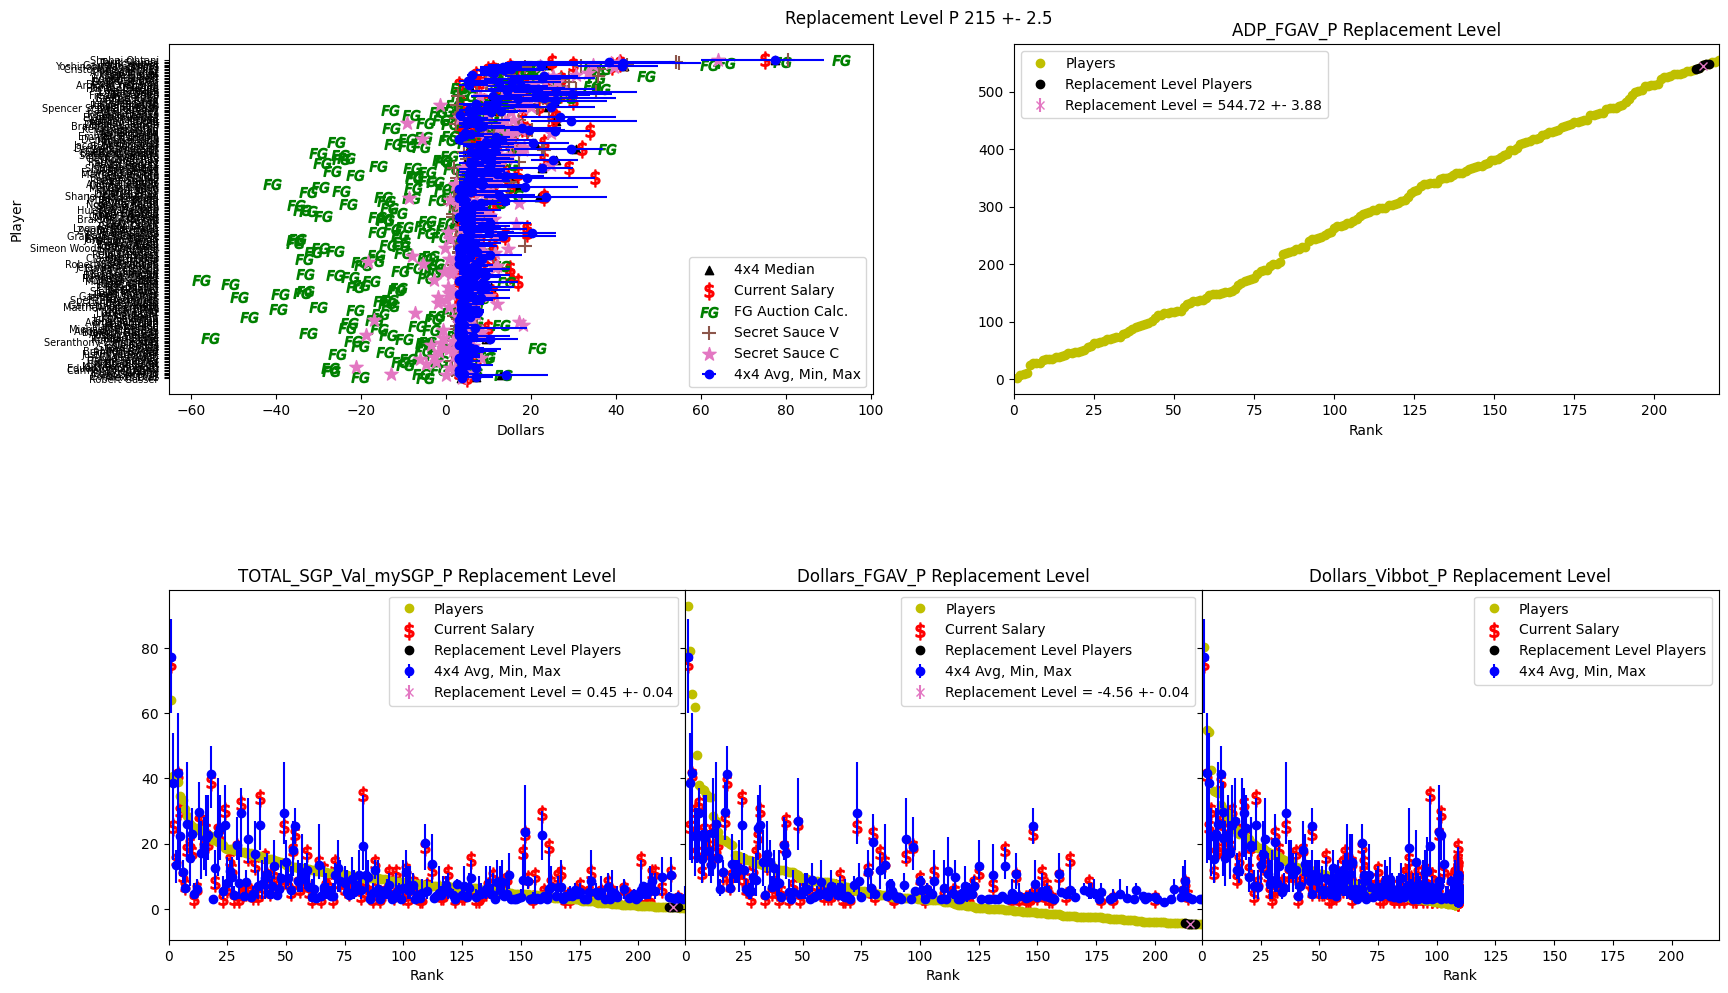

In [90]:
Replacement_Stats_df = pd.DataFrame()

pos_idx = 0

for pos,repl_level_mid in Replacement_Level.items():
    print('###################################')
    print(f'Position {pos} Replacement Level = {repl_level_mid}')
    print('###################################')

    This_Pos_df = Full_Merge_sorted_df[Full_Merge_sorted_df['Ottoneu Positions'].apply(lambda x : f"{pos}" in x.split('/'))]
    if pos == 'P':
        Pos_list = ['SP','RP','SP/RP','Util/SP']
        This_Pos_df = Full_Merge_sorted_df[Full_Merge_sorted_df['Ottoneu Positions'].isin(Pos_list)]
    if pos == 'Util':
        Not_Pos_list = ['SP','RP','SP/RP']
        This_Pos_df = Full_Merge_sorted_df[~Full_Merge_sorted_df['Ottoneu Positions'].isin(Not_Pos_list)]
    if pos == 'MI':
        Pos_list = ['2B','SS']
        This_Pos_df = Full_Merge_sorted_df[Full_Merge_sorted_df['Ottoneu Positions'].apply(lambda x : f"2B" in x.split('/'))]
        This_Pos_df = pd.concat([
            This_Pos_df,
            Full_Merge_sorted_df[Full_Merge_sorted_df['Ottoneu Positions'].apply(lambda x : f"SS" in x.split('/'))]

        ]).sort_values(by=['ADP_FGAV'])

    proj_idx = 0
    x_max = repl_level_mid+Replacement_window[pos]
    fig0 = plt.figure(figsize=(20,10))
    outer_subfig = fig0.subfigures(2, 1, wspace=0.07)
    upper_axes = outer_subfig[0].subplots(1, 2)
    lower_gs = outer_subfig[1].add_gridspec(1,len(Proj_cols)-1, wspace=0)
    lower_axes = lower_gs.subplots(sharey=True) # Because ADP is above
    #print(pos, repl_level_mid,' +- ',(Replacement_window[pos]/2))
    for proj_col in Proj_cols:
        this_axis = lower_axes[proj_idx-1]
        is_rank = False
        if 'ADP' in proj_col:
            is_rank = True
            this_axis = upper_axes[1]
        This_Pos_df[f'{proj_col}_{pos}_rank'] = This_Pos_df[f'{proj_col}'].rank(method="dense", na_option='bottom',ascending=is_rank)
        # this_axis = axs

        if proj_idx == 0:
            quick_plotting_fn(This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max],upper_axes[0])
        
        Replacement_level_df = This_Pos_df[(This_Pos_df[f'{proj_col}_{pos}_rank'] >= repl_level_mid-(Replacement_window[pos]/2)) \
                                              & (This_Pos_df[f'{proj_col}_{pos}_rank'] <= repl_level_mid+(Replacement_window[pos]/2))
                                            ].sort_values([f'{proj_col}_{pos}_rank'], ascending=is_rank)
        mean = Replacement_level_df[proj_col].mean()
        std = Replacement_level_df[proj_col].std()
        Replacement_Stats_df = pd.concat([
            Replacement_Stats_df,
            pd.DataFrame([{
                'POS':pos,
                'Stat': proj_col,
                'mean':mean,
                'std':std
            }])
        ])

        this_axis.plot(This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max][f'{proj_col}_{pos}_rank'],This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max][proj_col], 'yo', label='Players')
        if not is_rank:
            this_axis.errorbar(
                y=This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max]['Ottoneu_Avg'],
                x=This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max][f'{proj_col}_{pos}_rank'],
                yerr=[
                    This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max]['Ottoneu_Avg']-This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max]['Ottoneu_Min'],
                    This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max]['Ottoneu_Max']-This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max]['Ottoneu_Avg']
                ],
                fmt='o',
                color='blue',
                label='4x4 Avg, Min, Max'
            )
            this_axis.scatter(
                y=This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max]['Salary'],
                x=This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max][f'{proj_col}_{pos}_rank'],
                marker='$\\$$',
                color='red',
                s=150,
                label='Current Salary'
            )
        if len(Replacement_level_df[Replacement_level_df[f'{proj_col}_{pos}_rank'] == repl_level_mid][f'{proj_col}_{pos}_rank']) > 0.:
            this_axis.errorbar(x=[Replacement_level_df[Replacement_level_df[f'{proj_col}_{pos}_rank'] == repl_level_mid][f'{proj_col}_{pos}_rank'].unique()], y=[mean],yerr=[std], fmt='x',color='tab:pink',label=f'Replacement Level = {mean:0.2f} +- {std:0.2f}')
            
            print(f'Replacement Level {proj_col} {pos} {mean:0.2f} +- {std:0.2f}')
            display(Replacement_level_df)
        this_axis.plot(Replacement_level_df[f'{proj_col}_{pos}_rank'],Replacement_level_df[proj_col], 'ko',label='Replacement Level Players')
        this_axis.set_title(f'{proj_col}_{pos} Replacement Level')
        #this_axis.set_ylabel(proj_col)
        this_axis.set_xlabel('Rank')
        # ymin = 0.95*This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max][proj_col].min()
        # ymax = 1.05*This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max][proj_col].max()
        xmin=0.
        xmax = x_max
        # this_axis.set_ylim([ymin,ymax])
        this_axis.set_xlim([xmin,xmax])
        this_axis.legend(loc='upper right')
        if is_rank:
            this_axis.legend(loc='upper left')

        print(proj_col, mean, ' +- ', std)
        #print(Replacement_level_df.head(Replacement_window[pos]))
        # quick_plotting_fn(Replacement_level_df,this_axis)
        # plt.tight_layout()    
        # plt.show()
        #this_axis.errorbar(x=[Replacement_level_df[Replacement_level_df[f'{proj_col}_{pos}_rank'] == repl_level_mid]['Name']], y=[mean],yerr=[std], fmt='x',color='r',label='Repl Mean')
        proj_idx+=1
    pos_idx+=1   
    fig0.suptitle(f'Replacement Level {pos} {repl_level_mid} +- {(Replacement_window[pos]/2)}')   
    plt.tight_layout()
    plt.show()